# EMCAD — Final Qualitative Visualization and Result Figures
## ClinicDB replication + BraTS neuroimaging experiment

In [1]:
from pathlib import Path
import hashlib
import json
import os
import shutil
import subprocess
import sys
import tarfile
import zipfile

INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working")

EXPECTED_COMMIT = "26c9c31f731f749b62c5fe83f44376dac75f3aa8"

def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def select_unique(filename, label):
    files = sorted(set(INPUT.rglob(filename)))

    if not files:
        raise FileNotFoundError(
            f"{label} not found: {filename}\n"
            "Attach the exact saved notebook output listed in the first cell."
        )

    if len(files) == 1:
        return files[0]

    groups = {}
    for path in files:
        groups.setdefault(
            sha256(path),
            [],
        ).append(path)

    if len(groups) == 1:
        print(
            f"{label}: {len(files)} identical copies found; using first."
        )
        return files[0]

    raise RuntimeError(
        f"{label}: conflicting copies found:\n"
        + "\n".join(str(p) for p in files)
    )

def expected_hash(manifest, filename):
    for line in manifest.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) >= 2 and parts[-1] == filename:
            return parts[0]

    raise RuntimeError(
        f"{filename} is missing from checksum manifest {manifest}"
    )

def extract_tar(archive, destination):
    destination.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive, "r:gz") as tf:
        try:
            tf.extractall(
                destination,
                filter="fully_trusted",
            )
        except TypeError:
            tf.extractall(destination)

print("System Python:", sys.version.split()[0])
print("Mounted input roots:")
for path in sorted(INPUT.iterdir()):
    print(" -", path.name)


System Python: 3.13.15
Mounted input roots:
 - notebooks


In [2]:
# Locate only the artifacts produced by our completed notebooks.

env_archive = select_unique(
    "emcadenv.tar.gz",
    "Notebook 1 environment",
)

repo_archive = select_unique(
    "EMCAD_prepared.tar.gz",
    "Notebook 1 prepared repository",
)

notebook1_checksums = select_unique(
    "EMCAD_NOTEBOOK1_SHA256SUMS.txt",
    "Notebook 1 checksums",
)

clinic_results_zip = select_unique(
    "EMCAD_ClinicDB_5Run_Final_Results.zip",
    "ClinicDB final result package",
)

clinic_checksums = select_unique(
    "EMCAD_ClinicDB_5Run_Final_SHA256SUMS.txt",
    "ClinicDB final checksums",
)

brats_archive = select_unique(
    "EMCAD_BraTS_Part1_Output.tar.gz",
    "BraTS Part 1 prepared data",
)

brats_checksums = select_unique(
    "EMCAD_BraTS_Part1_SHA256SUMS.txt",
    "BraTS Part 1 checksums",
)

part4_archive = select_unique(
    "EMCAD_BraTS_Run1_Part4_State.tar.gz",
    "BraTS Part 4 state",
)

part4_checksums = select_unique(
    "EMCAD_BraTS_Run1_Part4_SHA256SUMS.txt",
    "BraTS Part 4 checksums",
)

print("Notebook 1:", env_archive.parent)
print("ClinicDB final:", clinic_results_zip.parent)
print("BraTS Part 1:", brats_archive.parent)
print("BraTS Part 4:", part4_archive.parent)


Notebook 1: /kaggle/input/notebooks/anirbanroysudipto/notebook-1-environment-preparation
ClinicDB final: /kaggle/input/notebooks/rinkyranisaha/testing-aggregation-and-evidence
BraTS Part 1: /kaggle/input/notebooks/rinkyranisaha/emcad-experiment-2-brats-preparation
BraTS Part 4: /kaggle/input/notebooks/rinkyranisaha/part-4-training-epochs-101-150


In [3]:
# Verify archives before extracting anything.

checks = [
    (
        env_archive,
        notebook1_checksums,
        "Notebook 1 environment",
    ),
    (
        repo_archive,
        notebook1_checksums,
        "Notebook 1 repository",
    ),
    (
        clinic_results_zip,
        clinic_checksums,
        "ClinicDB final results",
    ),
    (
        brats_archive,
        brats_checksums,
        "BraTS Part 1",
    ),
    (
        part4_archive,
        part4_checksums,
        "BraTS Part 4",
    ),
]

for path,manifest,label in checks:
    actual = sha256(path)
    expected = expected_hash(
        manifest,
        path.name,
    )

    if actual != expected:
        raise RuntimeError(
            f"{label} checksum mismatch:\n"
            f"expected {expected}\n"
            f"actual   {actual}"
        )

    print(label + " checksum: PASS")


Notebook 1 environment checksum: PASS
Notebook 1 repository checksum: PASS
ClinicDB final results checksum: PASS
BraTS Part 1 checksum: PASS
BraTS Part 4 checksum: PASS


In [4]:
# Restore the exact Python 3.8 EMCAD environment correctly.
#
# IMPORTANT:
# emcadenv.tar.gz is a conda-pack archive. It must be extracted INTO
# /kaggle/working/emcadenv, not into /kaggle/working itself.

ENV = WORK / "emcadenv"
REPO = WORK / "EMCAD"
BRATS = WORK / "EMCAD_BraTS_Part1_Output"
PART4 = WORK / "EMCAD_BraTS_Run1_Part4_State"
CLINIC = WORK / "EMCAD_FINAL_RESULTS"

for path in [
    ENV,
    REPO,
    BRATS,
    PART4,
    CLINIC,
]:
    if path.exists():
        shutil.rmtree(path)

ENV.mkdir(parents=True)

extract_tar(
    env_archive,
    ENV,
)

conda_unpack = ENV / "bin" / "conda-unpack"
python38 = ENV / "bin" / "python"

assert conda_unpack.is_file(), conda_unpack
assert python38.is_file(), python38

subprocess.run(
    [str(conda_unpack)],
    check=True,
)

# EMCAD_prepared.tar.gz contains a top-level EMCAD directory.
extract_tar(
    repo_archive,
    WORK,
)

# BraTS archives contain their own top-level package directories.
extract_tar(
    brats_archive,
    WORK,
)

extract_tar(
    part4_archive,
    WORK,
)

# The ClinicDB result ZIP was created with EMCAD_FINAL_RESULTS as root_dir,
# so its files are extracted directly into our chosen CLINIC directory.
CLINIC.mkdir(parents=True)
with zipfile.ZipFile(
    clinic_results_zip,
    "r",
) as zf:
    zf.extractall(CLINIC)

assert REPO.is_dir(), REPO
assert BRATS.is_dir(), BRATS
assert PART4.is_dir(), PART4

print("Environment restored:", ENV)
print("Repository restored:", REPO)
print("BraTS Part 1 restored:", BRATS)
print("BraTS Part 4 restored:", PART4)
print("ClinicDB final results restored:", CLINIC)


Environment restored: /kaggle/working/emcadenv
Repository restored: /kaggle/working/EMCAD
BraTS Part 1 restored: /kaggle/working/EMCAD_BraTS_Part1_Output
BraTS Part 4 restored: /kaggle/working/EMCAD_BraTS_Run1_Part4_State
ClinicDB final results restored: /kaggle/working/EMCAD_FINAL_RESULTS


In [5]:
# Fast integrity preflight before visualization/inference.

required_clinic = [
    CLINIC / "official_test_results.csv",
    CLINIC / "official_per_image_results.csv",
    CLINIC / "paper_reference_comparison.csv",
    CLINIC / "epoch_history_all_runs.csv",
    CLINIC / "AUTHOR_predictions_polyp",
]

for path in required_clinic:
    assert path.exists(), path

train_cache = sorted(
    (BRATS / "slice_cache" / "train").glob("*.pt")
)

val_cache = sorted(
    (BRATS / "slice_cache" / "val").glob("*.pt")
)

test_images = sorted(
    (BRATS / "test_volumes" / "images").glob("*.nii.gz")
)

test_labels = sorted(
    (BRATS / "test_volumes" / "labels").glob("*.nii.gz")
)

assert len(train_cache) == 388
assert len(val_cache) == 48
assert len(test_images) == 48
assert len(test_labels) == 48

for filename in [
    "best_through_epoch150.pth",
    "resume_epoch150.pth",
    "history_through_epoch150.csv",
    "part4_metadata.json",
]:
    path = PART4 / filename
    assert path.is_file(), path

    expected = expected_hash(
        part4_checksums,
        filename,
    )

    assert sha256(path) == expected, filename

part4_metadata = json.loads(
    (PART4 / "part4_metadata.json").read_text()
)

# Grounded in the completed Part 4/Part 5 run from this project.
assert int(
    part4_metadata["best_epoch_through_epoch_150"]
) == 139

assert abs(
    float(
        part4_metadata[
            "best_validation_dice_through_epoch_150"
        ]
    ) - 0.8977
) < 5e-4

print("ClinicDB result package: PASS")
print("BraTS prepared data: PASS")
print("BraTS Part 4 state: PASS")
print(
    "BraTS checkpoint selected from epoch:",
    part4_metadata["best_epoch_through_epoch_150"],
)
print(
    "Validation Dice at selected checkpoint:",
    f'{part4_metadata["best_validation_dice_through_epoch_150"]:.4f}',
)


ClinicDB result package: PASS
BraTS prepared data: PASS
BraTS Part 4 state: PASS
BraTS checkpoint selected from epoch: 139
Validation Dice at selected checkpoint: 0.8977


In [6]:
# Verify the restored legacy environment and GPU before the 5-minute
# BraTS inference stage.

subprocess.run(
    [
        str(python38),
        "-c",
        (
            "import sys, torch, torchvision, numpy, timm, cv2, "
            "nibabel, scipy, pandas, matplotlib; "
            "print('Python:', sys.version.split()[0]); "
            "print('PyTorch:', torch.__version__); "
            "print('Torchvision:', torchvision.__version__); "
            "print('NumPy:', numpy.__version__); "
            "print('timm:', timm.__version__); "
            "print('CUDA available:', torch.cuda.is_available()); "
            "print('GPU:', torch.cuda.get_device_name(0) "
            "if torch.cuda.is_available() else 'None'); "
            "assert sys.version_info[:2] == (3,8); "
            "assert torch.__version__.startswith('1.11.0'); "
            "assert numpy.__version__ == '1.22.4'; "
            "assert timm.__version__ == '0.6.12'; "
            "assert torch.cuda.is_available()"
        ),
    ],
    check=True,
)

print("Environment/GPU preflight: PASS")


Python: 3.8.20
PyTorch: 1.11.0+cu113
Torchvision: 0.12.0+cu113
NumPy: 1.22.4
timm: 0.6.12
CUDA available: True
GPU: Tesla T4
Environment/GPU preflight: PASS


## Generate all visual results

The next cell writes one self-contained visualization program and runs it with the exact EMCAD Python 3.8 environment.

It does two things:

**ClinicDB**
- uses the saved author predictions from our completed five-run replication;
- automatically selects the best run by official test Dice;
- shows difficult / median / strong test images.

**BraTS**
- loads the exact epoch-139 checkpoint already saved in Part 4;
- strictly verifies the model state;
- regenerates predictions for all 48 held-out patients using the same full-volume test preprocessing used in completed Part 5;
- computes Dice, IoU, sensitivity, specificity, precision, accuracy, and HD95;
- creates difficult / median / strong patient visualization.

This is inference and visualization only. There is no retraining and no test-based model selection.


In [7]:
from pathlib import Path

visual_code = '\nfrom pathlib import Path\nimport csv\nimport json\nimport math\nimport shutil\n\nimport cv2\nimport nibabel as nib\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn.functional as F\n\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nfrom matplotlib.patches import Patch\n\nfrom scipy.ndimage import (\n    binary_erosion,\n    distance_transform_edt,\n)\n\nfrom lib.networks import EMCADNet\n\n\n# =============================================================================\n# Paths / configuration\n# =============================================================================\n\nWORK = Path("/kaggle/working")\nREPO = WORK / "EMCAD"\nCLINIC = WORK / "EMCAD_FINAL_RESULTS"\nBRATS = WORK / "EMCAD_BraTS_Part1_Output"\nPART4 = WORK / "EMCAD_BraTS_Run1_Part4_State"\n\nOUT = WORK / "EMCAD_Visualization_Results"\n\nif OUT.exists():\n    shutil.rmtree(OUT)\n\nOUT.mkdir(parents=True)\n\nBRATS_PRED_DIR = OUT / "BraTS_predictions"\nBRATS_PRED_DIR.mkdir()\n\nIMG_SIZE = 352\nTHRESHOLD = 0.5\nTEST_BATCH_SIZE = 8\n\nIMAGENET_MEAN = torch.tensor(\n    [0.485, 0.456, 0.406]\n).view(3,1,1)\n\nIMAGENET_STD = torch.tensor(\n    [0.229, 0.224, 0.225]\n).view(3,1,1)\n\n\n# =============================================================================\n# General helpers\n# =============================================================================\n\ndef confusion_counts(prediction, target):\n    prediction = prediction.astype(bool)\n    target = target.astype(bool)\n\n    tp = int(\n        np.logical_and(\n            prediction,\n            target,\n        ).sum()\n    )\n\n    tn = int(\n        np.logical_and(\n            ~prediction,\n            ~target,\n        ).sum()\n    )\n\n    fp = int(\n        np.logical_and(\n            prediction,\n            ~target,\n        ).sum()\n    )\n\n    fn = int(\n        np.logical_and(\n            ~prediction,\n            target,\n        ).sum()\n    )\n\n    return tp,tn,fp,fn\n\n\ndef metrics_from_counts(tp,tn,fp,fn):\n    eps = 1e-6\n\n    return {\n        "dice": (\n            2*tp + eps\n        ) / (\n            2*tp + fp + fn + eps\n        ),\n        "iou": (\n            tp + eps\n        ) / (\n            tp + fp + fn + eps\n        ),\n        "sensitivity": (\n            tp + eps\n        ) / (\n            tp + fn + eps\n        ),\n        "specificity": (\n            tn + eps\n        ) / (\n            tn + fp + eps\n        ),\n        "precision": (\n            tp + eps\n        ) / (\n            tp + fp + eps\n        ),\n        "accuracy": (\n            tp + tn + eps\n        ) / (\n            tp + tn + fp + fn + eps\n        ),\n    }\n\n\ndef robust_display_normalize(image):\n    image = image.astype(np.float32)\n\n    values = image[\n        np.isfinite(image)\n        & (image != 0)\n    ]\n\n    if values.size == 0:\n        return np.zeros_like(\n            image,\n            dtype=np.float32,\n        )\n\n    low,high = np.percentile(\n        values,\n        [1,99],\n    )\n\n    if high <= low:\n        high = float(values.max())\n        low = float(values.min())\n\n    if high <= low:\n        return np.zeros_like(\n            image,\n            dtype=np.float32,\n        )\n\n    return np.clip(\n        (image-low)\n        / (high-low),\n        0,\n        1,\n    )\n\n\ndef save_figure(path):\n    plt.tight_layout()\n    plt.savefig(\n        path,\n        dpi=220,\n        bbox_inches="tight",\n    )\n    plt.close()\n\n\n# =============================================================================\n# ClinicDB: saved predictions from completed replication\n# =============================================================================\n\nofficial_runs = pd.read_csv(\n    CLINIC / "official_test_results.csv"\n)\n\nofficial_per_image = pd.read_csv(\n    CLINIC / "official_per_image_results.csv"\n)\n\npaper_reference = pd.read_csv(\n    CLINIC / "paper_reference_comparison.csv"\n)\n\nepoch_history = pd.read_csv(\n    CLINIC / "epoch_history_all_runs.csv"\n)\n\nbest_run = (\n    official_runs\n    .sort_values(\n        "dice",\n        ascending=False,\n    )\n    .iloc[0]\n)\n\nclinic_run_id = str(\n    best_run["run_id"]\n)\n\nclinic_run_number = int(\n    best_run["run_number"]\n)\n\nclinic_rows = (\n    official_per_image[\n        official_per_image[\n            "run_id"\n        ].astype(str)\n        == clinic_run_id\n    ]\n    .copy()\n    .sort_values("Dice")\n    .reset_index(drop=True)\n)\n\nassert len(clinic_rows) == 62\n\nclinic_pred_dir = (\n    CLINIC\n    / "AUTHOR_predictions_polyp"\n    / clinic_run_id\n    / "ClinicDB"\n    / "test"\n)\n\nclinic_image_dir = (\n    REPO\n    / "data"\n    / "polyp"\n    / "target"\n    / "ClinicDB"\n    / "test"\n    / "images"\n)\n\nclinic_mask_dir = (\n    REPO\n    / "data"\n    / "polyp"\n    / "target"\n    / "ClinicDB"\n    / "test"\n    / "masks"\n)\n\nassert clinic_pred_dir.is_dir()\nassert clinic_image_dir.is_dir()\nassert clinic_mask_dir.is_dir()\n\n\ndef resolve_same_stem(root, name):\n    direct = root / name\n\n    if direct.is_file():\n        return direct\n\n    stem = Path(name).stem\n\n    matches = [\n        path\n        for path in root.iterdir()\n        if path.is_file()\n        and path.stem == stem\n    ]\n\n    if len(matches) != 1:\n        raise RuntimeError(\n            f"Could not uniquely resolve {name} in {root}: {matches}"\n        )\n\n    return matches[0]\n\n\ndef read_rgb(path):\n    image = cv2.imread(\n        str(path),\n        cv2.IMREAD_COLOR,\n    )\n\n    if image is None:\n        raise RuntimeError(path)\n\n    return cv2.cvtColor(\n        image,\n        cv2.COLOR_BGR2RGB,\n    )\n\n\ndef read_binary_mask(path):\n    mask = cv2.imread(\n        str(path),\n        cv2.IMREAD_GRAYSCALE,\n    )\n\n    if mask is None:\n        raise RuntimeError(path)\n\n    return mask > 0\n\n\ndef clinic_overlay(image, gt, pred):\n    canvas = cv2.cvtColor(\n        image,\n        cv2.COLOR_RGB2BGR,\n    ).copy()\n\n    gt_u8 = (\n        gt.astype(np.uint8)\n        * 255\n    )\n\n    pred_u8 = (\n        pred.astype(np.uint8)\n        * 255\n    )\n\n    gt_contours,_ = cv2.findContours(\n        gt_u8,\n        cv2.RETR_EXTERNAL,\n        cv2.CHAIN_APPROX_SIMPLE,\n    )\n\n    pred_contours,_ = cv2.findContours(\n        pred_u8,\n        cv2.RETR_EXTERNAL,\n        cv2.CHAIN_APPROX_SIMPLE,\n    )\n\n    # Ground truth boundary = green; prediction boundary = red.\n    cv2.drawContours(\n        canvas,\n        gt_contours,\n        -1,\n        (0,255,0),\n        2,\n    )\n\n    cv2.drawContours(\n        canvas,\n        pred_contours,\n        -1,\n        (0,0,255),\n        2,\n    )\n\n    return cv2.cvtColor(\n        canvas,\n        cv2.COLOR_BGR2RGB,\n    )\n\n\nn = len(clinic_rows)\n\nclinic_selected = pd.concat(\n    [\n        clinic_rows.head(2),\n        clinic_rows.iloc[\n            max(0,n//2-1):\n            min(n,n//2+1)\n        ],\n        clinic_rows.tail(2),\n    ]\n).drop_duplicates(\n    subset=["Name"]\n).reset_index(drop=True)\n\nclinic_selected.to_csv(\n    OUT / "ClinicDB_selected_cases.csv",\n    index=False,\n)\n\nfig,axes = plt.subplots(\n    len(clinic_selected),\n    4,\n    figsize=(\n        15,\n        3.4*len(clinic_selected),\n    ),\n)\n\nif len(clinic_selected) == 1:\n    axes = np.expand_dims(\n        axes,\n        axis=0,\n    )\n\nfor row_index,(_,row) in enumerate(\n    clinic_selected.iterrows()\n):\n    name = str(\n        row["Name"]\n    )\n\n    image_path = resolve_same_stem(\n        clinic_image_dir,\n        name,\n    )\n\n    gt_path = resolve_same_stem(\n        clinic_mask_dir,\n        name,\n    )\n\n    pred_path = resolve_same_stem(\n        clinic_pred_dir,\n        name,\n    )\n\n    image = read_rgb(\n        image_path\n    )\n\n    gt = read_binary_mask(\n        gt_path\n    )\n\n    pred = read_binary_mask(\n        pred_path\n    )\n\n    target_shape = pred.shape\n\n    if image.shape[:2] != target_shape:\n        image = cv2.resize(\n            image,\n            (\n                target_shape[1],\n                target_shape[0],\n            ),\n            interpolation=cv2.INTER_LINEAR,\n        )\n\n    if gt.shape != target_shape:\n        gt = cv2.resize(\n            gt.astype(np.uint8),\n            (\n                target_shape[1],\n                target_shape[0],\n            ),\n            interpolation=cv2.INTER_NEAREST,\n        ).astype(bool)\n\n    overlay = clinic_overlay(\n        image,\n        gt,\n        pred,\n    )\n\n    panels = [\n        (\n            image,\n            "Original",\n        ),\n        (\n            gt,\n            "Ground Truth",\n        ),\n        (\n            pred,\n            "EMCAD Prediction",\n        ),\n        (\n            overlay,\n            (\n                f"{name} | Dice={float(row[\'Dice\']):.3f}, "\n                f"IoU={float(row[\'IoU\']):.3f}"\n            ),\n        ),\n    ]\n\n    for column,(panel,title) in enumerate(\n        panels\n    ):\n        ax = axes[\n            row_index,\n            column,\n        ]\n\n        if panel.ndim == 2:\n            ax.imshow(\n                panel,\n                cmap="gray",\n            )\n        else:\n            ax.imshow(panel)\n\n        ax.set_title(\n            title,\n            fontsize=10,\n        )\n        ax.axis("off")\n\nfig.suptitle(\n    (\n        "ClinicDB — Difficult, Median, and Strong Segmentation Cases\\n"\n        "Green boundary = ground truth | Red boundary = prediction"\n    ),\n    fontsize=15,\n    y=1.01,\n)\n\nsave_figure(\n    OUT / "01_ClinicDB_Qualitative_Gallery.png"\n)\n\n\n# ClinicDB per-image distribution for the best test run.\n\nfig = plt.figure(\n    figsize=(9,4.8)\n)\n\nplt.hist(\n    clinic_rows["Dice"],\n    bins=15,\n)\n\nplt.axvline(\n    clinic_rows["Dice"].mean(),\n    linestyle="--",\n    label=(\n        "Per-image mean = "\n        f"{clinic_rows[\'Dice\'].mean():.3f}"\n    ),\n)\n\nplt.xlabel("Dice")\nplt.ylabel("Test images")\nplt.title(\n    (\n        "ClinicDB — Per-image Dice Distribution\\n"\n        f"Selected official run {clinic_run_number}"\n    )\n)\nplt.legend()\n\nsave_figure(\n    OUT / "02_ClinicDB_Per_Image_Dice.png"\n)\n\n\n# ClinicDB five-run validation Dice curves.\n\nfig = plt.figure(\n    figsize=(10,5.5)\n)\n\nfor run_number,group in (\n    epoch_history[\n        epoch_history["split"]\n        == "val"\n    ]\n    .groupby("run_number")\n):\n    group = group.sort_values(\n        "epoch"\n    )\n\n    plt.plot(\n        group["epoch"],\n        group["dice"],\n        linewidth=1.2,\n        label=f"Run {int(run_number)}",\n    )\n\nplt.xlabel("Epoch")\nplt.ylabel("Validation Dice")\nplt.title(\n    "ClinicDB — Validation Dice Across Five Replication Runs"\n)\nplt.legend(\n    ncol=3,\n    fontsize=8,\n)\n\nsave_figure(\n    OUT / "03_ClinicDB_Validation_Dice_5Runs.png"\n)\n\n\n# ClinicDB paper vs replicated five-run test Dice.\n\npublished_dice = float(\n    paper_reference[\n        "published_dice"\n    ].iloc[0]\n)\n\nreplicated_mean = float(\n    paper_reference[\n        "replicated_5run_mean_dice"\n    ].iloc[0]\n)\n\nreplicated_std = float(\n    official_runs["dice"].std(\n        ddof=1\n    )\n)\n\nfig = plt.figure(\n    figsize=(7.5,5)\n)\n\nlabels = [\n    "Published\\nPVT-EMCAD-B2",\n    "Our 5-run\\nreplication",\n]\n\nvalues = [\n    published_dice,\n    replicated_mean,\n]\n\nbars = plt.bar(\n    labels,\n    values,\n)\n\nplt.errorbar(\n    [1],\n    [replicated_mean],\n    yerr=[replicated_std],\n    fmt="none",\n    capsize=5,\n)\n\nplt.ylim(\n    max(0, min(values)-0.08),\n    1.0,\n)\n\nplt.ylabel("Dice")\nplt.title(\n    "ClinicDB — Published vs Replicated Dice"\n)\n\nfor bar,value in zip(\n    bars,\n    values,\n):\n    plt.text(\n        bar.get_x()\n        + bar.get_width()/2,\n        value + 0.008,\n        f"{value*100:.2f}%",\n        ha="center",\n        fontsize=10,\n    )\n\nsave_figure(\n    OUT / "04_ClinicDB_Published_vs_Replication.png"\n)\n\n\n# =============================================================================\n# BraTS: final-best checkpoint from Part 4\n# =============================================================================\n\npart4_metadata = json.loads(\n    (\n        PART4\n        / "part4_metadata.json"\n    ).read_text()\n)\n\nbest_epoch = int(\n    part4_metadata[\n        "best_epoch_through_epoch_150"\n    ]\n)\n\nbest_val_dice = float(\n    part4_metadata[\n        "best_validation_dice_through_epoch_150"\n    ]\n)\n\nassert best_epoch == 139\n\ndevice = torch.device(\n    "cuda:0"\n    if torch.cuda.is_available()\n    else "cpu"\n)\n\nif device.type != "cuda":\n    raise RuntimeError(\n        "Enable a Kaggle T4 GPU for the BraTS visualization inference."\n    )\n\nmodel = EMCADNet(\n    num_classes=1,\n    kernel_sizes=[1,3,5],\n    expansion_factor=2,\n    dw_parallel=True,\n    add=True,\n    lgag_ks=3,\n    activation="relu6",\n    encoder="pvt_v2_b2",\n    pretrain=False,\n    pretrained_dir="./pretrained_pth/pvt/",\n)\n\ncheckpoint_path = (\n    PART4\n    / "best_through_epoch150.pth"\n)\n\nstate = torch.load(\n    checkpoint_path,\n    map_location=device,\n)\n\n# Authoritative architecture compatibility check.\nmodel.load_state_dict(\n    state,\n    strict=True,\n)\n\nmodel = model.to(\n    device\n)\n\nmodel.eval()\n\nprint()\nprint("BraTS model verification")\nprint("Selected checkpoint:",checkpoint_path)\nprint("Best epoch:",best_epoch)\nprint("Best validation Dice:",f"{best_val_dice:.4f}")\nprint(\n    "Model parameters:",\n    sum(\n        p.numel()\n        for p in model.parameters()\n    ),\n)\nprint("Strict state-dict load: PASS")\n\n\n# =============================================================================\n# BraTS full-volume test helpers copied from the completed Part 5 protocol\n# =============================================================================\n\ndef case_id(path):\n    name = Path(path).name\n\n    if name.endswith(\n        ".nii.gz"\n    ):\n        return name[:-7]\n\n    return Path(name).stem\n\n\ndef load_test_case(\n    image_path,\n    label_path,\n):\n    image_nii = nib.load(\n        str(image_path)\n    )\n\n    label_nii = nib.load(\n        str(label_path)\n    )\n\n    image_np = np.asarray(\n        image_nii.dataobj,\n        dtype=np.float32,\n    )\n\n    label_np = np.asarray(\n        label_nii.dataobj,\n        dtype=np.int16,\n    )\n\n    if image_np.ndim != 4:\n        raise RuntimeError(\n            f"Expected 4D MRI, got {image_np.shape}: {image_path}"\n        )\n\n    modality_axes = [\n        axis\n        for axis,size\n        in enumerate(\n            image_np.shape\n        )\n        if size == 4\n    ]\n\n    if len(modality_axes) != 1:\n        raise RuntimeError(\n            (\n                "Cannot uniquely identify modality axis: "\n                f"{image_path.name} -> {image_np.shape}"\n            )\n        )\n\n    image_np = np.moveaxis(\n        image_np,\n        modality_axes[0],\n        0,\n    )\n\n    if image_np.shape[1:] != label_np.shape:\n        raise RuntimeError(\n            (\n                "Image/label spatial mismatch: "\n                f"{image_np.shape} vs {label_np.shape}"\n            )\n        )\n\n    # Part 1 metadata: 0=FLAIR, 2=T1-Gd, 3=T2.\n    selected = torch.from_numpy(\n        image_np[\n            [0,2,3]\n        ]\n    ).float()\n\n    label = torch.from_numpy(\n        label_np\n    )\n\n    whole_tumour = (\n        label > 0\n    ).to(\n        torch.uint8\n    )\n\n    brain = (\n        selected.abs().sum(\n            dim=0\n        ) > 0\n    )\n\n    normalized = torch.zeros_like(\n        selected\n    )\n\n    for channel in range(\n        selected.shape[0]\n    ):\n        values = selected[\n            channel\n        ][\n            brain\n        ]\n\n        if values.numel() == 0:\n            raise RuntimeError(\n                f"Empty brain region: {image_path.name}"\n            )\n\n        mu = values.mean()\n        sigma = values.std()\n\n        if sigma <= 0:\n            raise RuntimeError(\n                (\n                    "Zero intensity variance: "\n                    f"{image_path.name}, channel={channel}"\n                )\n            )\n\n        zscore = (\n            selected[channel]\n            - mu\n        ) / sigma\n\n        zscore = zscore.clamp(\n            -5.0,\n            5.0,\n        )\n\n        normalized[\n            channel\n        ][\n            brain\n        ] = (\n            zscore[brain]\n            + 5.0\n        ) / 10.0\n\n    return (\n        normalized,\n        whole_tumour,\n        brain,\n        image_nii.affine,\n        image_nii.header.copy(),\n    )\n\n\ndef preprocess_test_batch(\n    batch,\n    device,\n):\n    batch = batch.to(\n        device,\n        non_blocking=True,\n    ).float()\n\n    batch = F.interpolate(\n        batch,\n        size=(\n            IMG_SIZE,\n            IMG_SIZE,\n        ),\n        mode="bilinear",\n        align_corners=False,\n    )\n\n    mean_tensor = IMAGENET_MEAN.to(\n        device\n    )\n\n    std_tensor = IMAGENET_STD.to(\n        device\n    )\n\n    return (\n        batch\n        - mean_tensor\n    ) / std_tensor\n\n\ndef hd95_surface_distance(\n    prediction,\n    target,\n    spacing,\n):\n    prediction = prediction.astype(\n        bool\n    )\n\n    target = target.astype(\n        bool\n    )\n\n    if (\n        not prediction.any()\n        or not target.any()\n    ):\n        return float("nan")\n\n    structure = np.ones(\n        (3,3,3),\n        dtype=bool,\n    )\n\n    pred_surface = np.logical_xor(\n        prediction,\n        binary_erosion(\n            prediction,\n            structure=structure,\n            border_value=0,\n        ),\n    )\n\n    target_surface = np.logical_xor(\n        target,\n        binary_erosion(\n            target,\n            structure=structure,\n            border_value=0,\n        ),\n    )\n\n    if (\n        not pred_surface.any()\n        or not target_surface.any()\n    ):\n        return float("nan")\n\n    distance_to_target = (\n        distance_transform_edt(\n            ~target_surface,\n            sampling=spacing,\n        )\n    )\n\n    distance_to_prediction = (\n        distance_transform_edt(\n            ~pred_surface,\n            sampling=spacing,\n        )\n    )\n\n    distances = np.concatenate(\n        [\n            distance_to_target[\n                pred_surface\n            ],\n            distance_to_prediction[\n                target_surface\n            ],\n        ]\n    )\n\n    return float(\n        np.percentile(\n            distances,\n            95,\n        )\n    )\n\n\ndef infer_case(\n    image_path,\n    label_path,\n):\n    (\n        image,\n        target,\n        brain,\n        affine,\n        header,\n    ) = load_test_case(\n        image_path,\n        label_path,\n    )\n\n    height,width,depth = target.shape\n\n    prediction = torch.zeros(\n        (\n            height,\n            width,\n            depth,\n        ),\n        dtype=torch.uint8,\n    )\n\n    z_indices = [\n        z\n        for z in range(depth)\n        if brain[:,:,z].any().item()\n    ]\n\n    model.eval()\n\n    with torch.no_grad():\n        for start in range(\n            0,\n            len(z_indices),\n            TEST_BATCH_SIZE,\n        ):\n            current_z = z_indices[\n                start:\n                start+TEST_BATCH_SIZE\n            ]\n\n            batch = torch.stack(\n                [\n                    image[:,:,:,z]\n                    for z in current_z\n                ],\n                dim=0,\n            )\n\n            batch = preprocess_test_batch(\n                batch,\n                device,\n            )\n\n            outputs = model(\n                batch\n            )\n\n            if not isinstance(\n                outputs,\n                list,\n            ):\n                outputs = [\n                    outputs\n                ]\n\n            if len(outputs) != 4:\n                raise RuntimeError(\n                    (\n                        "Expected four EMCAD outputs, "\n                        f"got {len(outputs)}."\n                    )\n                )\n\n            # Same final p4 output used in Part 5.\n            logits = outputs[-1]\n\n            logits = F.interpolate(\n                logits,\n                size=(\n                    height,\n                    width,\n                ),\n                mode="bilinear",\n                align_corners=False,\n            )\n\n            predicted = (\n                torch.sigmoid(\n                    logits\n                )\n                >= THRESHOLD\n            ).to(\n                torch.uint8\n            ).cpu()\n\n            for local_index,z in enumerate(\n                current_z\n            ):\n                prediction[:,:,z] = (\n                    predicted[\n                        local_index,\n                        0,\n                    ]\n                )\n\n    target_np = target.numpy().astype(\n        bool\n    )\n\n    prediction_np = (\n        prediction.numpy().astype(\n            bool\n        )\n    )\n\n    tp,tn,fp,fn = confusion_counts(\n        prediction_np,\n        target_np,\n    )\n\n    metrics = metrics_from_counts(\n        tp,\n        tn,\n        fp,\n        fn,\n    )\n\n    spacing = tuple(\n        float(value)\n        for value in header.get_zooms()[:3]\n    )\n\n    metrics[\n        "hd95"\n    ] = hd95_surface_distance(\n        prediction_np,\n        target_np,\n        spacing,\n    )\n\n    metrics["tp"] = tp\n    metrics["tn"] = tn\n    metrics["fp"] = fp\n    metrics["fn"] = fn\n\n    return (\n        image,\n        target_np,\n        prediction_np,\n        affine,\n        header,\n        metrics,\n    )\n\n\nsplit = json.loads(\n    (\n        BRATS\n        / "patient_split.json"\n    ).read_text()\n)\n\ntest_patients = list(\n    split["test"]\n)\n\nassert len(test_patients) == 48\n\nimage_root = (\n    BRATS\n    / "test_volumes"\n    / "images"\n)\n\nlabel_root = (\n    BRATS\n    / "test_volumes"\n    / "labels"\n)\n\nimages = {\n    case_id(path):path\n    for path in image_root.glob(\n        "*.nii.gz"\n    )\n}\n\nlabels = {\n    case_id(path):path\n    for path in label_root.glob(\n        "*.nii.gz"\n    )\n}\n\nassert set(\n    test_patients\n) == set(\n    images\n)\n\nassert set(\n    test_patients\n) == set(\n    labels\n)\n\n\n# =============================================================================\n# BraTS full held-out inference\n# =============================================================================\n\nbrats_rows = []\n\nglobal_tp = 0\nglobal_tn = 0\nglobal_fp = 0\nglobal_fn = 0\n\nfor index,patient_id in enumerate(\n    test_patients,\n    start=1,\n):\n    (\n        image,\n        target,\n        prediction,\n        affine,\n        header,\n        metrics,\n    ) = infer_case(\n        images[\n            patient_id\n        ],\n        labels[\n            patient_id\n        ],\n    )\n\n    row = {\n        "patient_id":patient_id,\n        "dice":metrics["dice"],\n        "iou":metrics["iou"],\n        "sensitivity":metrics[\n            "sensitivity"\n        ],\n        "specificity":metrics[\n            "specificity"\n        ],\n        "precision":metrics[\n            "precision"\n        ],\n        "accuracy":metrics[\n            "accuracy"\n        ],\n        "hd95":metrics["hd95"],\n        "tp":metrics["tp"],\n        "tn":metrics["tn"],\n        "fp":metrics["fp"],\n        "fn":metrics["fn"],\n    }\n\n    brats_rows.append(\n        row\n    )\n\n    global_tp += metrics["tp"]\n    global_tn += metrics["tn"]\n    global_fp += metrics["fp"]\n    global_fn += metrics["fn"]\n\n    pred_header = header.copy()\n    pred_header.set_data_dtype(\n        np.uint8\n    )\n\n    prediction_nii = nib.Nifti1Image(\n        prediction.astype(\n            np.uint8\n        ),\n        affine,\n        header=pred_header,\n    )\n\n    nib.save(\n        prediction_nii,\n        str(\n            BRATS_PRED_DIR\n            / f"{patient_id}_WT_pred.nii.gz"\n        ),\n    )\n\n    hd95_text = (\n        f"{metrics[\'hd95\']:.2f}"\n        if math.isfinite(\n            metrics["hd95"]\n        )\n        else "NaN"\n    )\n\n    print(\n        (\n            f"BraTS {index:02d}/48 {patient_id}: "\n            f"Dice={metrics[\'dice\']:.4f}, "\n            f"IoU={metrics[\'iou\']:.4f}, "\n            f"HD95={hd95_text}"\n        )\n    )\n\n\nbrats_df = pd.DataFrame(\n    brats_rows\n)\n\nbrats_df.to_csv(\n    OUT\n    / "BraTS_test_patient_metrics_regenerated.csv",\n    index=False,\n)\n\n\ndef macro_summary(\n    dataframe,\n    metric,\n):\n    values = (\n        dataframe[\n            metric\n        ]\n        .replace(\n            [np.inf,-np.inf],\n            np.nan,\n        )\n        .dropna()\n        .astype(float)\n    )\n\n    return {\n        "mean":float(\n            values.mean()\n        ),\n        "std":float(\n            values.std(\n                ddof=1\n            )\n        ),\n        "n":int(\n            len(values)\n        ),\n    }\n\n\nmacro = {\n    metric:macro_summary(\n        brats_df,\n        metric,\n    )\n    for metric in [\n        "dice",\n        "iou",\n        "sensitivity",\n        "specificity",\n        "precision",\n        "accuracy",\n        "hd95",\n    ]\n}\n\nglobal_metrics = metrics_from_counts(\n    global_tp,\n    global_tn,\n    global_fp,\n    global_fn,\n)\n\nbrats_summary = {\n    "patients":48,\n    "best_validation_epoch":best_epoch,\n    "best_validation_dice":best_val_dice,\n    "macro_patient_metrics":macro,\n    "global_voxel_metrics":global_metrics,\n    "global_counts":{\n        "tp":int(global_tp),\n        "tn":int(global_tn),\n        "fp":int(global_fp),\n        "fn":int(global_fn),\n    },\n    "empty_prediction_patients":int(\n        (\n            (\n                brats_df["tp"]\n                + brats_df["fp"]\n            ) == 0\n        ).sum()\n    ),\n}\n\n(\n    OUT\n    / "BraTS_regenerated_test_summary.json"\n).write_text(\n    json.dumps(\n        brats_summary,\n        indent=2,\n    )\n)\n\nprint()\nprint("BraTS regenerated final test")\nprint(\n    "Macro Dice:",\n    f"{macro[\'dice\'][\'mean\']:.4f}",\n    "±",\n    f"{macro[\'dice\'][\'std\']:.4f}",\n)\nprint(\n    "Macro IoU:",\n    f"{macro[\'iou\'][\'mean\']:.4f}",\n    "±",\n    f"{macro[\'iou\'][\'std\']:.4f}",\n)\nprint(\n    "Global Dice:",\n    f"{global_metrics[\'dice\']:.4f}",\n)\nprint(\n    "Global IoU:",\n    f"{global_metrics[\'iou\']:.4f}",\n)\nprint(\n    "HD95:",\n    f"{macro[\'hd95\'][\'mean\']:.3f}",\n    "±",\n    f"{macro[\'hd95\'][\'std\']:.3f}",\n)\nprint(\n    "Empty predictions:",\n    brats_summary[\n        "empty_prediction_patients"\n    ],\n)\n\n\n# Compare against the completed Part 5 result from this same project.\nexpected_completed_part5 = {\n    "macro_dice":0.8613,\n    "macro_iou":0.7700,\n    "global_dice":0.8984,\n    "global_iou":0.8155,\n    "hd95_mean":16.862,\n}\n\ncomparison_rows = []\n\nfor metric,actual,expected in [\n    (\n        "macro_dice",\n        macro["dice"]["mean"],\n        expected_completed_part5[\n            "macro_dice"\n        ],\n    ),\n    (\n        "macro_iou",\n        macro["iou"]["mean"],\n        expected_completed_part5[\n            "macro_iou"\n        ],\n    ),\n    (\n        "global_dice",\n        global_metrics["dice"],\n        expected_completed_part5[\n            "global_dice"\n        ],\n    ),\n    (\n        "global_iou",\n        global_metrics["iou"],\n        expected_completed_part5[\n            "global_iou"\n        ],\n    ),\n    (\n        "hd95_mean",\n        macro["hd95"]["mean"],\n        expected_completed_part5[\n            "hd95_mean"\n        ],\n    ),\n]:\n    comparison_rows.append(\n        {\n            "metric":metric,\n            "regenerated":actual,\n            "completed_part5":expected,\n            "absolute_difference":abs(\n                actual-expected\n            ),\n        }\n    )\n\ncomparison_df = pd.DataFrame(\n    comparison_rows\n)\n\ncomparison_df.to_csv(\n    OUT\n    / "BraTS_regenerated_vs_completed_Part5.csv",\n    index=False,\n)\n\nprint()\nprint(\n    comparison_df.to_string(\n        index=False\n    )\n)\n\n\n# =============================================================================\n# BraTS qualitative gallery\n# =============================================================================\n\nsorted_brats = (\n    brats_df\n    .sort_values("dice")\n    .reset_index(drop=True)\n)\n\nn = len(\n    sorted_brats\n)\n\nbrats_selected = pd.concat(\n    [\n        sorted_brats.head(2),\n        sorted_brats.iloc[\n            max(0,n//2-1):\n            min(n,n//2+1)\n        ],\n        sorted_brats.tail(2),\n    ]\n).drop_duplicates(\n    subset=[\n        "patient_id"\n    ]\n).reset_index(\n    drop=True\n)\n\nbrats_selected.to_csv(\n    OUT\n    / "BraTS_selected_cases.csv",\n    index=False,\n)\n\n\ndef load_saved_prediction(\n    patient_id,\n):\n    path = (\n        BRATS_PRED_DIR\n        / f"{patient_id}_WT_pred.nii.gz"\n    )\n\n    return (\n        nib.load(\n            str(path)\n        )\n        .get_fdata()\n        > 0\n    )\n\n\nfig,axes = plt.subplots(\n    len(brats_selected),\n    5,\n    figsize=(\n        18,\n        3.6*len(brats_selected),\n    ),\n)\n\nif len(brats_selected) == 1:\n    axes = np.expand_dims(\n        axes,\n        0,\n    )\n\nfor row_index,(_,row) in enumerate(\n    brats_selected.iterrows()\n):\n    patient_id = str(\n        row["patient_id"]\n    )\n\n    (\n        image,\n        target,\n        brain,\n        affine,\n        header,\n    ) = load_test_case(\n        images[\n            patient_id\n        ],\n        labels[\n            patient_id\n        ],\n    )\n\n    prediction = load_saved_prediction(\n        patient_id\n    )\n\n    tumour_area = target.numpy().sum(\n        axis=(0,1)\n    )\n\n    z = int(\n        np.argmax(\n            tumour_area\n        )\n    )\n\n    flair = image[\n        0,\n        :,\n        :,\n        z,\n    ].numpy()\n\n    gt_slice = target[\n        :,\n        :,\n        z,\n    ].numpy().astype(\n        bool\n    )\n\n    pred_slice = prediction[\n        :,\n        :,\n        z,\n    ].astype(\n        bool\n    )\n\n    flair_display = robust_display_normalize(\n        flair\n    )\n\n    gt_overlay = np.stack(\n        [\n            flair_display,\n            flair_display,\n            flair_display,\n        ],\n        axis=-1,\n    )\n\n    gt_overlay[\n        gt_slice\n    ] = [0,1,0]\n\n    error_overlay = np.stack(\n        [\n            flair_display,\n            flair_display,\n            flair_display,\n        ],\n        axis=-1,\n    )\n\n    gt_only = (\n        gt_slice\n        & ~pred_slice\n    )\n\n    pred_only = (\n        pred_slice\n        & ~gt_slice\n    )\n\n    overlap = (\n        gt_slice\n        & pred_slice\n    )\n\n    # Green = GT only, red = prediction only, yellow = overlap.\n    error_overlay[\n        gt_only\n    ] = [0,1,0]\n\n    error_overlay[\n        pred_only\n    ] = [1,0,0]\n\n    error_overlay[\n        overlap\n    ] = [1,1,0]\n\n    panels = [\n        (\n            flair_display,\n            "FLAIR MRI",\n        ),\n        (\n            gt_slice,\n            "Ground Truth WT",\n        ),\n        (\n            pred_slice,\n            "EMCAD Prediction",\n        ),\n        (\n            gt_overlay,\n            "Ground Truth Overlay",\n        ),\n        (\n            error_overlay,\n            (\n                f"{patient_id} | z={z}\\n"\n                f"Dice={float(row[\'dice\']):.3f}, "\n                f"IoU={float(row[\'iou\']):.3f}, "\n                f"HD95={float(row[\'hd95\']):.2f}"\n            ),\n        ),\n    ]\n\n    for column,(panel,title) in enumerate(\n        panels\n    ):\n        ax = axes[\n            row_index,\n            column,\n        ]\n\n        if panel.ndim == 2:\n            ax.imshow(\n                panel,\n                cmap="gray",\n            )\n        else:\n            ax.imshow(\n                panel\n            )\n\n        ax.set_title(\n            title,\n            fontsize=9,\n        )\n\n        ax.axis(\n            "off"\n        )\n\nfig.suptitle(\n    (\n        "BraTS — Difficult, Median, and Strong Held-out Patients\\n"\n        "Error overlay: green=GT only, red=prediction only, yellow=overlap"\n    ),\n    fontsize=15,\n    y=1.01,\n)\n\nsave_figure(\n    OUT / "05_BraTS_Qualitative_Gallery.png"\n)\n\n\n# BraTS per-patient Dice.\n\nfig = plt.figure(\n    figsize=(9,4.8)\n)\n\nplt.hist(\n    brats_df["dice"],\n    bins=15,\n)\n\nplt.axvline(\n    macro["dice"]["mean"],\n    linestyle="--",\n    label=(\n        "Macro mean = "\n        f"{macro[\'dice\'][\'mean\']:.3f}"\n    ),\n)\n\nplt.xlabel("Dice")\nplt.ylabel("Held-out patients")\nplt.title(\n    "BraTS — Per-patient Whole-Tumour Dice"\n)\nplt.legend()\n\nsave_figure(\n    OUT / "06_BraTS_Per_Patient_Dice.png"\n)\n\n\n# BraTS IoU.\n\nfig = plt.figure(\n    figsize=(9,4.8)\n)\n\nplt.hist(\n    brats_df["iou"],\n    bins=15,\n)\n\nplt.axvline(\n    macro["iou"]["mean"],\n    linestyle="--",\n    label=(\n        "Macro mean = "\n        f"{macro[\'iou\'][\'mean\']:.3f}"\n    ),\n)\n\nplt.xlabel("IoU")\nplt.ylabel("Held-out patients")\nplt.title(\n    "BraTS — Per-patient Whole-Tumour IoU"\n)\nplt.legend()\n\nsave_figure(\n    OUT / "07_BraTS_Per_Patient_IoU.png"\n)\n\n\n# BraTS HD95.\n\nfinite_hd95 = (\n    brats_df[\n        "hd95"\n    ]\n    .replace(\n        [np.inf,-np.inf],\n        np.nan,\n    )\n    .dropna()\n)\n\nfig = plt.figure(\n    figsize=(9,4.8)\n)\n\nplt.hist(\n    finite_hd95,\n    bins=15,\n)\n\nplt.axvline(\n    finite_hd95.mean(),\n    linestyle="--",\n    label=(\n        "Mean = "\n        f"{finite_hd95.mean():.2f}"\n    ),\n)\n\nplt.xlabel("HD95")\nplt.ylabel("Held-out patients")\nplt.title(\n    "BraTS — Per-patient HD95"\n)\nplt.legend()\n\nsave_figure(\n    OUT / "08_BraTS_HD95.png"\n)\n\n\n# BraTS validation trajectory through the stage that already contains\n# the final selected checkpoint.\n\nbrats_history = pd.read_csv(\n    PART4\n    / "history_through_epoch150.csv"\n)\n\nassert len(\n    brats_history\n) == 150\n\nfig = plt.figure(\n    figsize=(10,5)\n)\n\nplt.plot(\n    brats_history["epoch"],\n    brats_history["val_dice"],\n    linewidth=1.3,\n)\n\nplt.axvline(\n    best_epoch,\n    linestyle="--",\n    label=(\n        f"Final selected epoch = {best_epoch}"\n    ),\n)\n\nplt.scatter(\n    [best_epoch],\n    [best_val_dice],\n    s=50,\n)\n\nplt.xlabel("Epoch")\nplt.ylabel("Validation Dice")\nplt.title(\n    (\n        "BraTS — Validation Dice Through Epoch 150\\n"\n        "Completed Part 5 retained epoch 139 as the final best checkpoint"\n    )\n)\n\nplt.legend()\n\nsave_figure(\n    OUT / "09_BraTS_Validation_Dice_to_Epoch150.png"\n)\n\n\n# =============================================================================\n# Result-summary image\n# =============================================================================\n\nclinic_mean = float(\n    official_runs[\n        "dice"\n    ].mean()\n)\n\nclinic_std = float(\n    official_runs[\n        "dice"\n    ].std(\n        ddof=1\n    )\n)\n\nclinic_iou_mean = float(\n    official_runs[\n        "iou"\n    ].mean()\n)\n\nclinic_iou_std = float(\n    official_runs[\n        "iou"\n    ].std(\n        ddof=1\n    )\n)\n\nclinic_hd95_mean = float(\n    official_runs[\n        "HD95"\n    ].mean()\n)\n\nclinic_hd95_std = float(\n    official_runs[\n        "HD95"\n    ].std(\n        ddof=1\n    )\n)\n\nsummary_rows = [\n    {\n        "Experiment":"ClinicDB replication",\n        "Evaluation":"5-run test mean",\n        "Dice_mean":clinic_mean,\n        "Dice_std":clinic_std,\n        "IoU_mean":clinic_iou_mean,\n        "IoU_std":clinic_iou_std,\n        "HD95_mean":clinic_hd95_mean,\n        "HD95_std":clinic_hd95_std,\n    },\n    {\n        "Experiment":"BraTS WT",\n        "Evaluation":"48-patient macro",\n        "Dice_mean":macro[\n            "dice"\n        ][\n            "mean"\n        ],\n        "Dice_std":macro[\n            "dice"\n        ][\n            "std"\n        ],\n        "IoU_mean":macro[\n            "iou"\n        ][\n            "mean"\n        ],\n        "IoU_std":macro[\n            "iou"\n        ][\n            "std"\n        ],\n        "HD95_mean":macro[\n            "hd95"\n        ][\n            "mean"\n        ],\n        "HD95_std":macro[\n            "hd95"\n        ][\n            "std"\n        ],\n    },\n]\n\nsummary_df = pd.DataFrame(\n    summary_rows\n)\n\nsummary_df.to_csv(\n    OUT\n    / "EMCAD_visual_summary_metrics.csv",\n    index=False,\n)\n\n\nfig,axes = plt.subplots(\n    1,\n    2,\n    figsize=(13,5),\n)\n\n# Left: ClinicDB reproducibility.\nclinic_values = [\n    published_dice,\n    clinic_mean,\n]\n\nclinic_labels = [\n    "Published",\n    "Replication\\n5-run mean",\n]\n\nbars = axes[0].bar(\n    clinic_labels,\n    clinic_values,\n)\n\naxes[0].errorbar(\n    [1],\n    [clinic_mean],\n    yerr=[clinic_std],\n    fmt="none",\n    capsize=5,\n)\n\naxes[0].set_ylim(\n    0.85,\n    1.0,\n)\n\naxes[0].set_ylabel(\n    "Dice"\n)\n\naxes[0].set_title(\n    "Experiment 1 — ClinicDB"\n)\n\nfor bar,value in zip(\n    bars,\n    clinic_values,\n):\n    axes[0].text(\n        bar.get_x()\n        + bar.get_width()/2,\n        value + 0.005,\n        f"{value*100:.2f}%",\n        ha="center",\n    )\n\n# Right: BraTS final test metrics.\nbrats_labels = [\n    "Macro Dice",\n    "Macro IoU",\n    "Global Dice",\n    "Global IoU",\n]\n\nbrats_values = [\n    macro[\n        "dice"\n    ][\n        "mean"\n    ],\n    macro[\n        "iou"\n    ][\n        "mean"\n    ],\n    global_metrics[\n        "dice"\n    ],\n    global_metrics[\n        "iou"\n    ],\n]\n\nbars = axes[1].bar(\n    brats_labels,\n    brats_values,\n)\n\naxes[1].set_ylim(\n    0,\n    1.0,\n)\n\naxes[1].set_ylabel(\n    "Score"\n)\n\naxes[1].set_title(\n    "Experiment 2 — BraTS Whole Tumour"\n)\n\naxes[1].tick_params(\n    axis="x",\n    rotation=20,\n)\n\nfor bar,value in zip(\n    bars,\n    brats_values,\n):\n    axes[1].text(\n        bar.get_x()\n        + bar.get_width()/2,\n        value + 0.02,\n        f"{value:.3f}",\n        ha="center",\n        fontsize=9,\n    )\n\nfig.suptitle(\n    (\n        "EMCAD Experimental Results\\n"\n        "Panels summarize different datasets/tasks; scores are not a direct domain-gap subtraction."\n    ),\n    fontsize=14,\n)\n\nsave_figure(\n    OUT / "10_EMCAD_Result_Summary.png"\n)\n\n\n# =============================================================================\n# Compact text report and output archive\n# =============================================================================\n\nreport = {\n    "ClinicDB":{\n        "selected_best_run_number":clinic_run_number,\n        "selected_best_run_id":clinic_run_id,\n        "selected_run_test_dice":float(\n            best_run[\n                "dice"\n            ]\n        ),\n        "five_run_mean_dice":clinic_mean,\n        "five_run_std_dice":clinic_std,\n        "five_run_mean_iou":clinic_iou_mean,\n        "five_run_std_iou":clinic_iou_std,\n        "five_run_mean_hd95":clinic_hd95_mean,\n        "five_run_std_hd95":clinic_hd95_std,\n        "published_dice":published_dice,\n    },\n    "BraTS":{\n        "checkpoint_epoch":best_epoch,\n        "validation_dice":best_val_dice,\n        "patients":48,\n        "macro_dice":macro[\n            "dice"\n        ],\n        "macro_iou":macro[\n            "iou"\n        ],\n        "macro_hd95":macro[\n            "hd95"\n        ],\n        "global_dice":global_metrics[\n            "dice"\n        ],\n        "global_iou":global_metrics[\n            "iou"\n        ],\n        "empty_prediction_patients":brats_summary[\n            "empty_prediction_patients"\n        ],\n    },\n}\n\n(\n    OUT\n    / "EMCAD_Visualization_Report.json"\n).write_text(\n    json.dumps(\n        report,\n        indent=2,\n    )\n)\n\narchive = shutil.make_archive(\n    str(\n        WORK\n        / "EMCAD_Visualization_Results"\n    ),\n    "zip",\n    root_dir=WORK,\n    base_dir=OUT.name,\n)\n\nprint()\nprint("="*76)\nprint("VISUALIZATION COMPLETE")\nprint("="*76)\nprint("ClinicDB selected run:",clinic_run_number)\nprint(\n    "ClinicDB 5-run Dice:",\n    f"{clinic_mean:.4f} ± {clinic_std:.4f}",\n)\nprint(\n    "BraTS macro Dice:",\n    f"{macro[\'dice\'][\'mean\']:.4f} ± {macro[\'dice\'][\'std\']:.4f}",\n)\nprint(\n    "BraTS global Dice:",\n    f"{global_metrics[\'dice\']:.4f}",\n)\nprint(\n    "BraTS HD95:",\n    f"{macro[\'hd95\'][\'mean\']:.3f} ± {macro[\'hd95\'][\'std\']:.3f}",\n)\nprint("Archive:",archive)\nprint("="*76)\n'

visual_script_path = REPO / "emcad_final_visualization.py"
visual_script_path.write_text(visual_code)
print("Visualization script:", visual_script_path)
print("Lines:", len(visual_code.splitlines()))


Visualization script: /kaggle/working/EMCAD/emcad_final_visualization.py
Lines: 2284


In [8]:
# Compile before running the expensive inference.
subprocess.run(
    [
        str(python38),
        "-m",
        "py_compile",
        str(
            REPO
            / "emcad_final_visualization.py"
        ),
    ],
    cwd=REPO,
    check=True,
)

print("Python 3.8 syntax check: PASS")


Python 3.8 syntax check: PASS


In [9]:
# Run ClinicDB visualization + 48-patient BraTS inference/visualization.

stdout_path = (
    WORK
    / "EMCAD_Visualization_stdout.log"
)

with stdout_path.open("w") as log:
    process = subprocess.Popen(
        [
            str(python38),
            "-u",
            "emcad_final_visualization.py",
        ],
        cwd=REPO,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line,end="")
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Visualization failed with return code {return_code}. "
        f"See {stdout_path}"
    )

print("Visualization execution: PASS")


Model pvt_v2_b2 backbone:  created, param count: 24849856
Model EMCAD decoder:  created, param count: 1913515

BraTS model verification
Selected checkpoint: /kaggle/working/EMCAD_BraTS_Run1_Part4_State/best_through_epoch150.pth
Best epoch: 139
Best validation Dice: 0.8977
Model parameters: 26764411
Strict state-dict load: PASS
BraTS 01/48 BRATS_333: Dice=0.8341, IoU=0.7154, HD95=10.63
BraTS 02/48 BRATS_037: Dice=0.9006, IoU=0.8191, HD95=2.83
BraTS 03/48 BRATS_082: Dice=0.9581, IoU=0.9195, HD95=2.24
BraTS 04/48 BRATS_016: Dice=0.8902, IoU=0.8022, HD95=44.69
BraTS 05/48 BRATS_099: Dice=0.8836, IoU=0.7915, HD95=27.66
BraTS 06/48 BRATS_361: Dice=0.9288, IoU=0.8671, HD95=1.73
BraTS 07/48 BRATS_293: Dice=0.8469, IoU=0.7345, HD95=91.39
BraTS 08/48 BRATS_129: Dice=0.9339, IoU=0.8759, HD95=3.00
BraTS 09/48 BRATS_399: Dice=0.9436, IoU=0.8932, HD95=1.73
BraTS 10/48 BRATS_438: Dice=0.5965, IoU=0.4251, HD95=64.41
BraTS 11/48 BRATS_474: Dice=0.9298, IoU=0.8689, HD95=24.66
BraTS 12/48 BRATS_396: Dice

## Display the main qualitative results

The following cells only display PNGs already generated by the verified visualization program.


01_ClinicDB_Qualitative_Gallery.png


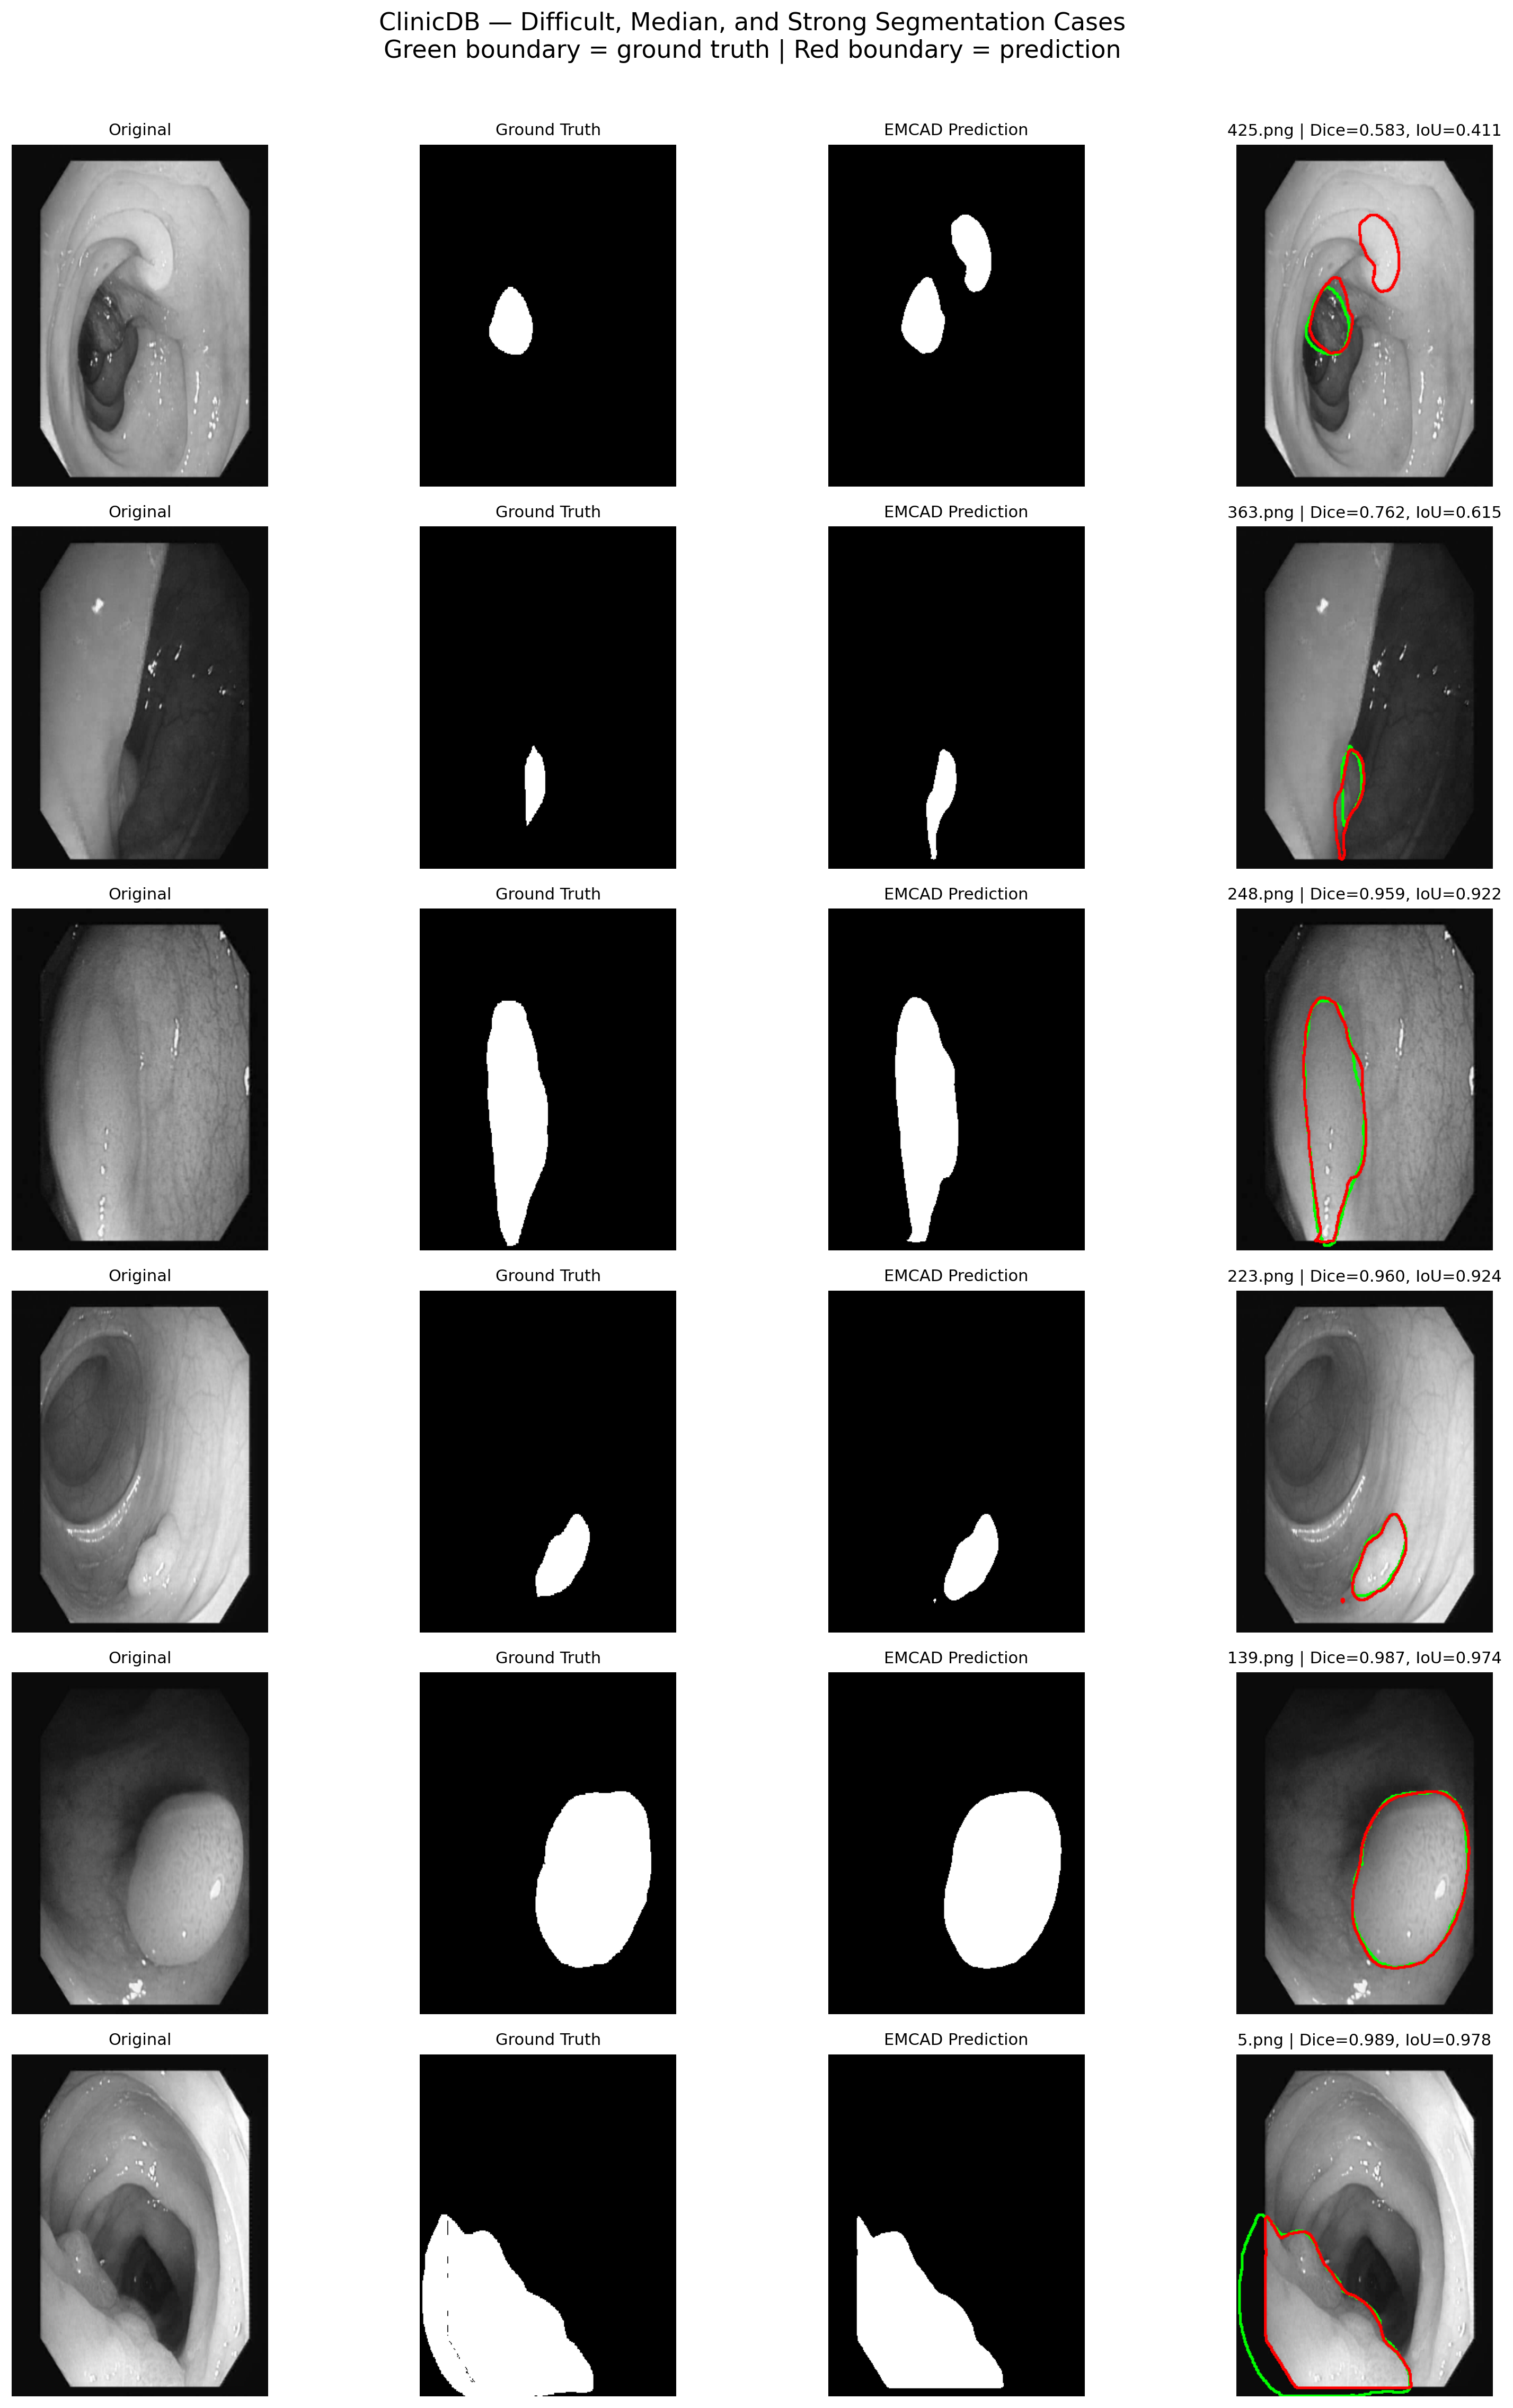

05_BraTS_Qualitative_Gallery.png


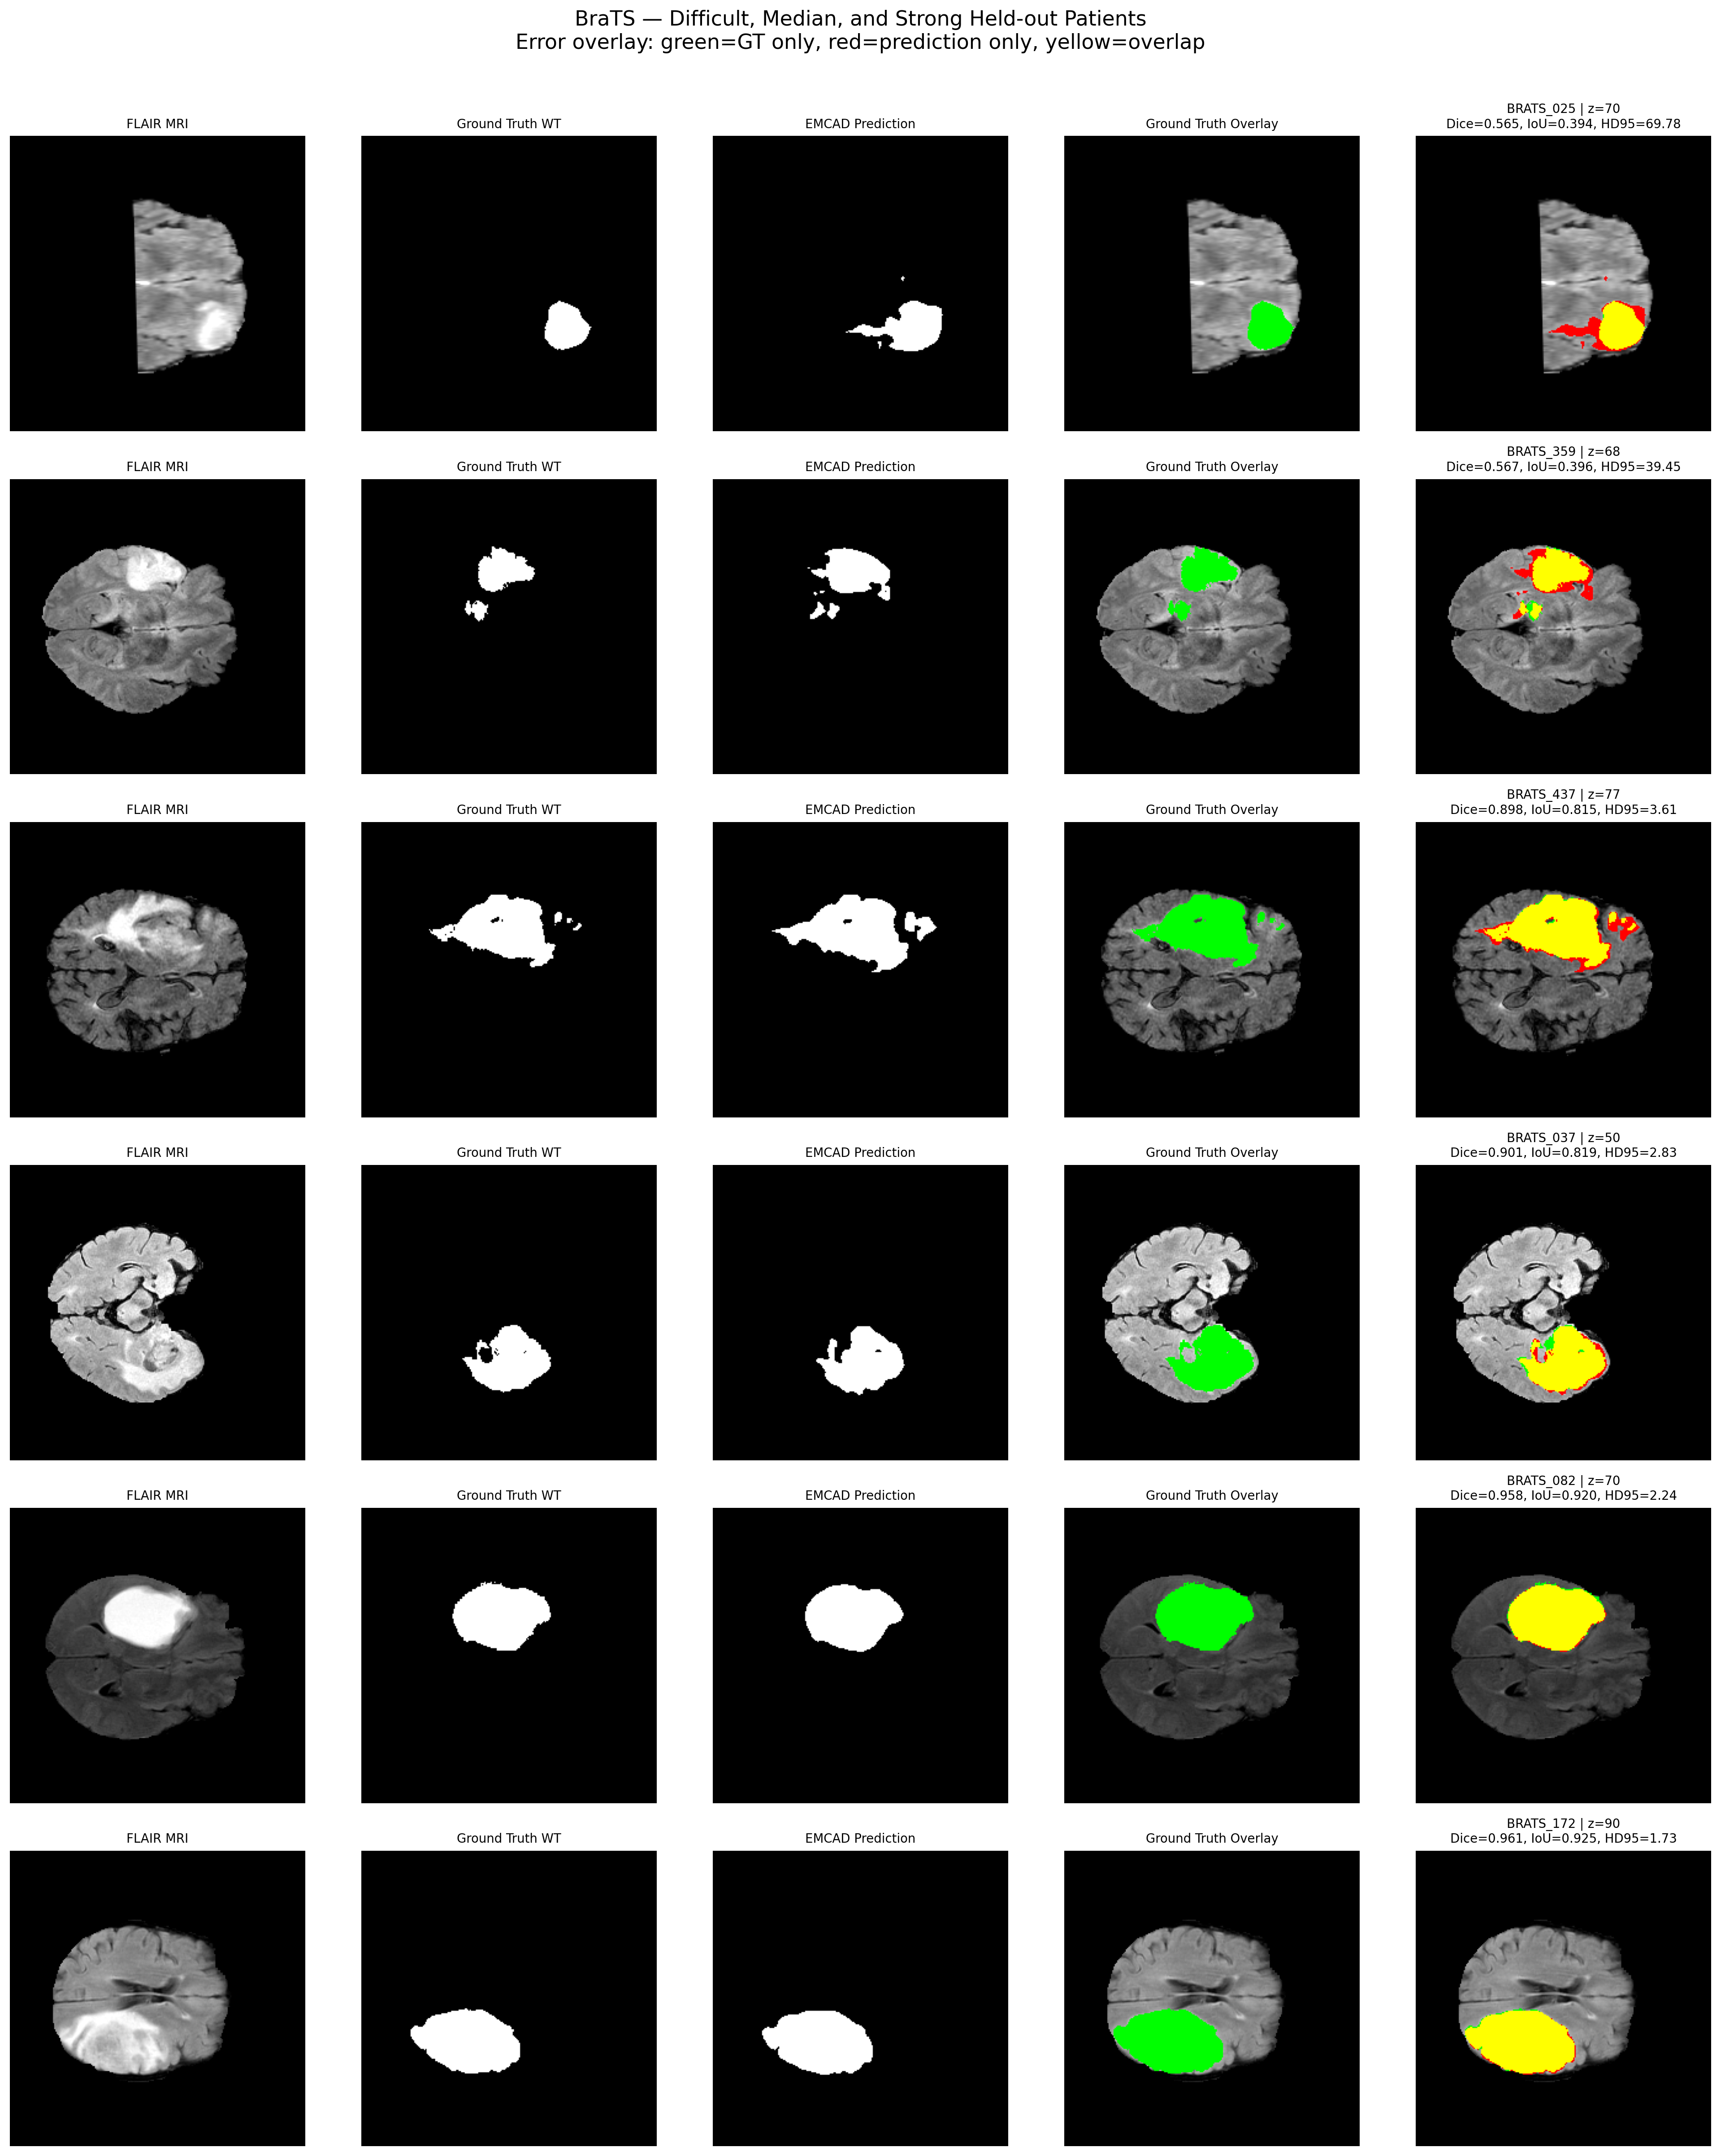

In [10]:
from IPython.display import display, Image

OUT = WORK / "EMCAD_Visualization_Results"

for filename in [
    "01_ClinicDB_Qualitative_Gallery.png",
    "05_BraTS_Qualitative_Gallery.png",
]:
    path = OUT / filename
    assert path.is_file(), path
    print(filename)
    display(
        Image(
            filename=str(path)
        )
    )


02_ClinicDB_Per_Image_Dice.png


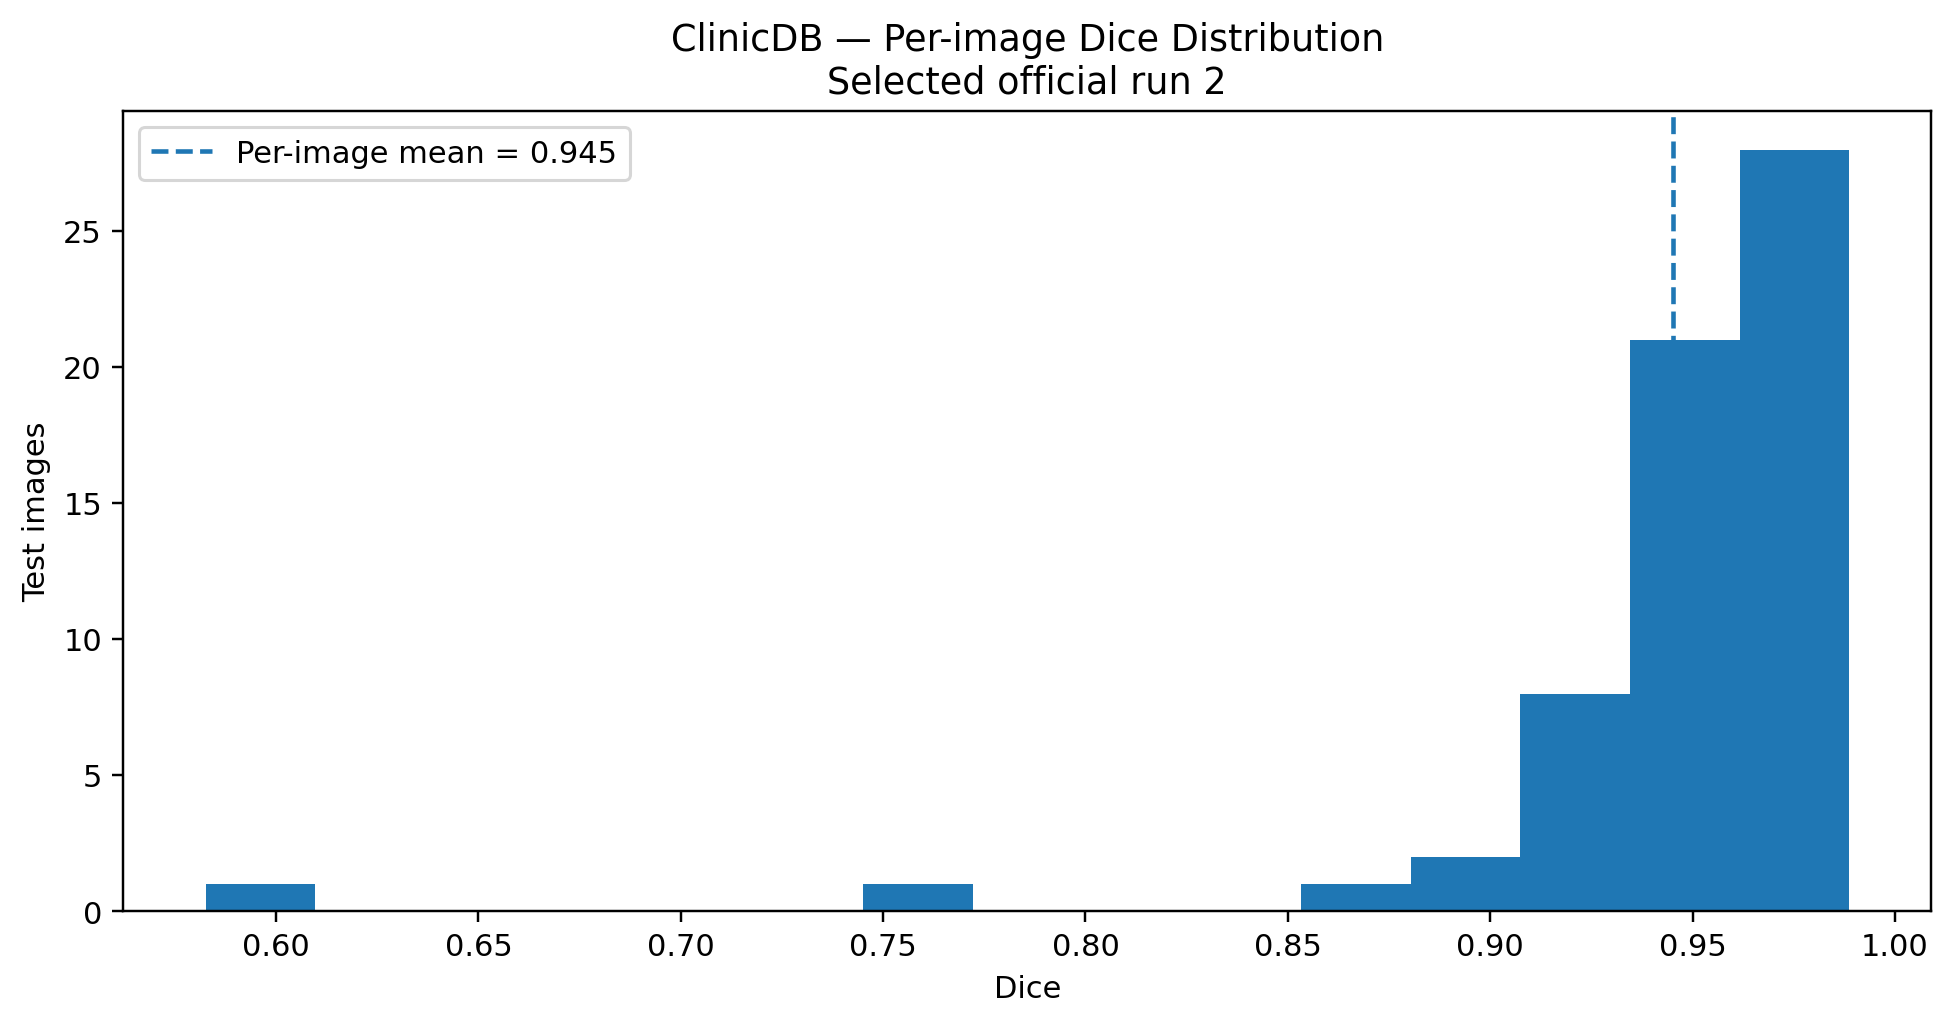

03_ClinicDB_Validation_Dice_5Runs.png


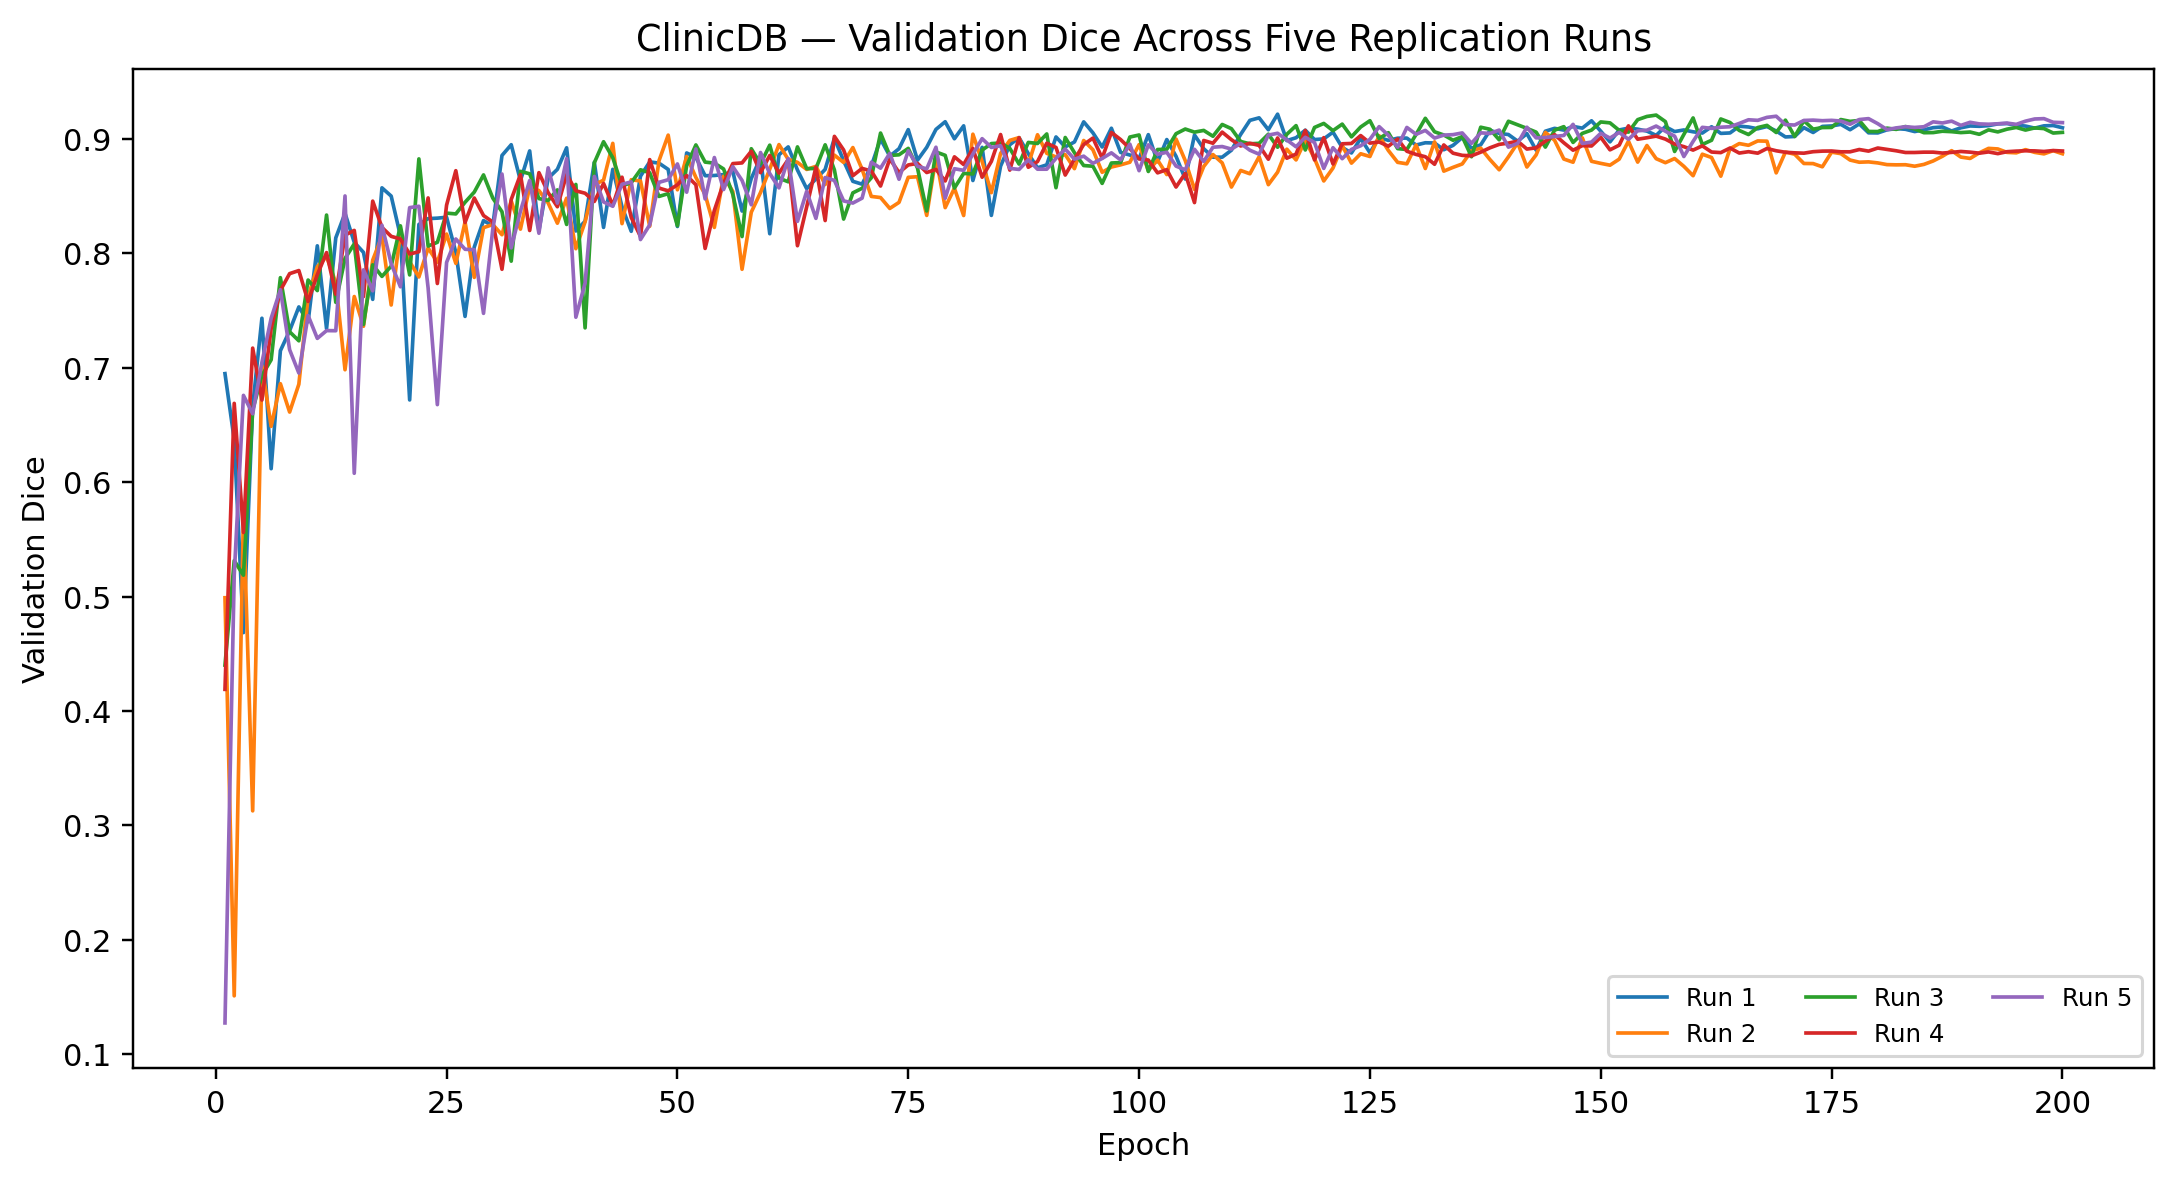

04_ClinicDB_Published_vs_Replication.png


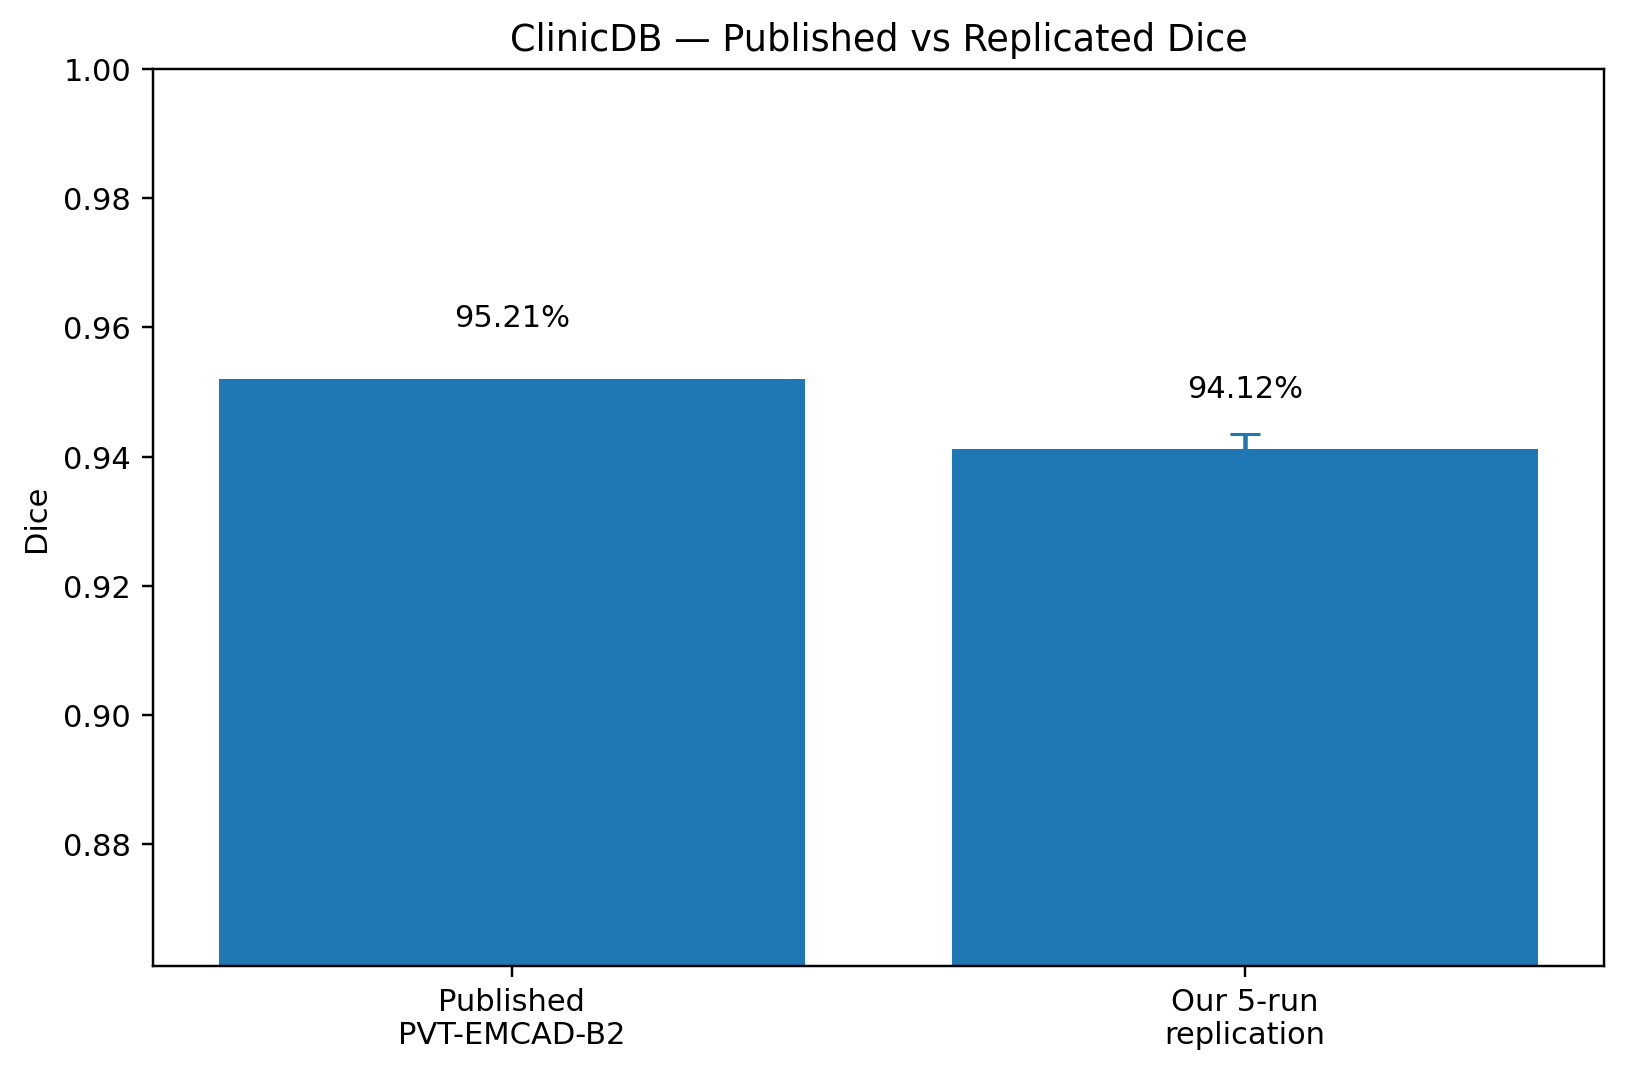

06_BraTS_Per_Patient_Dice.png


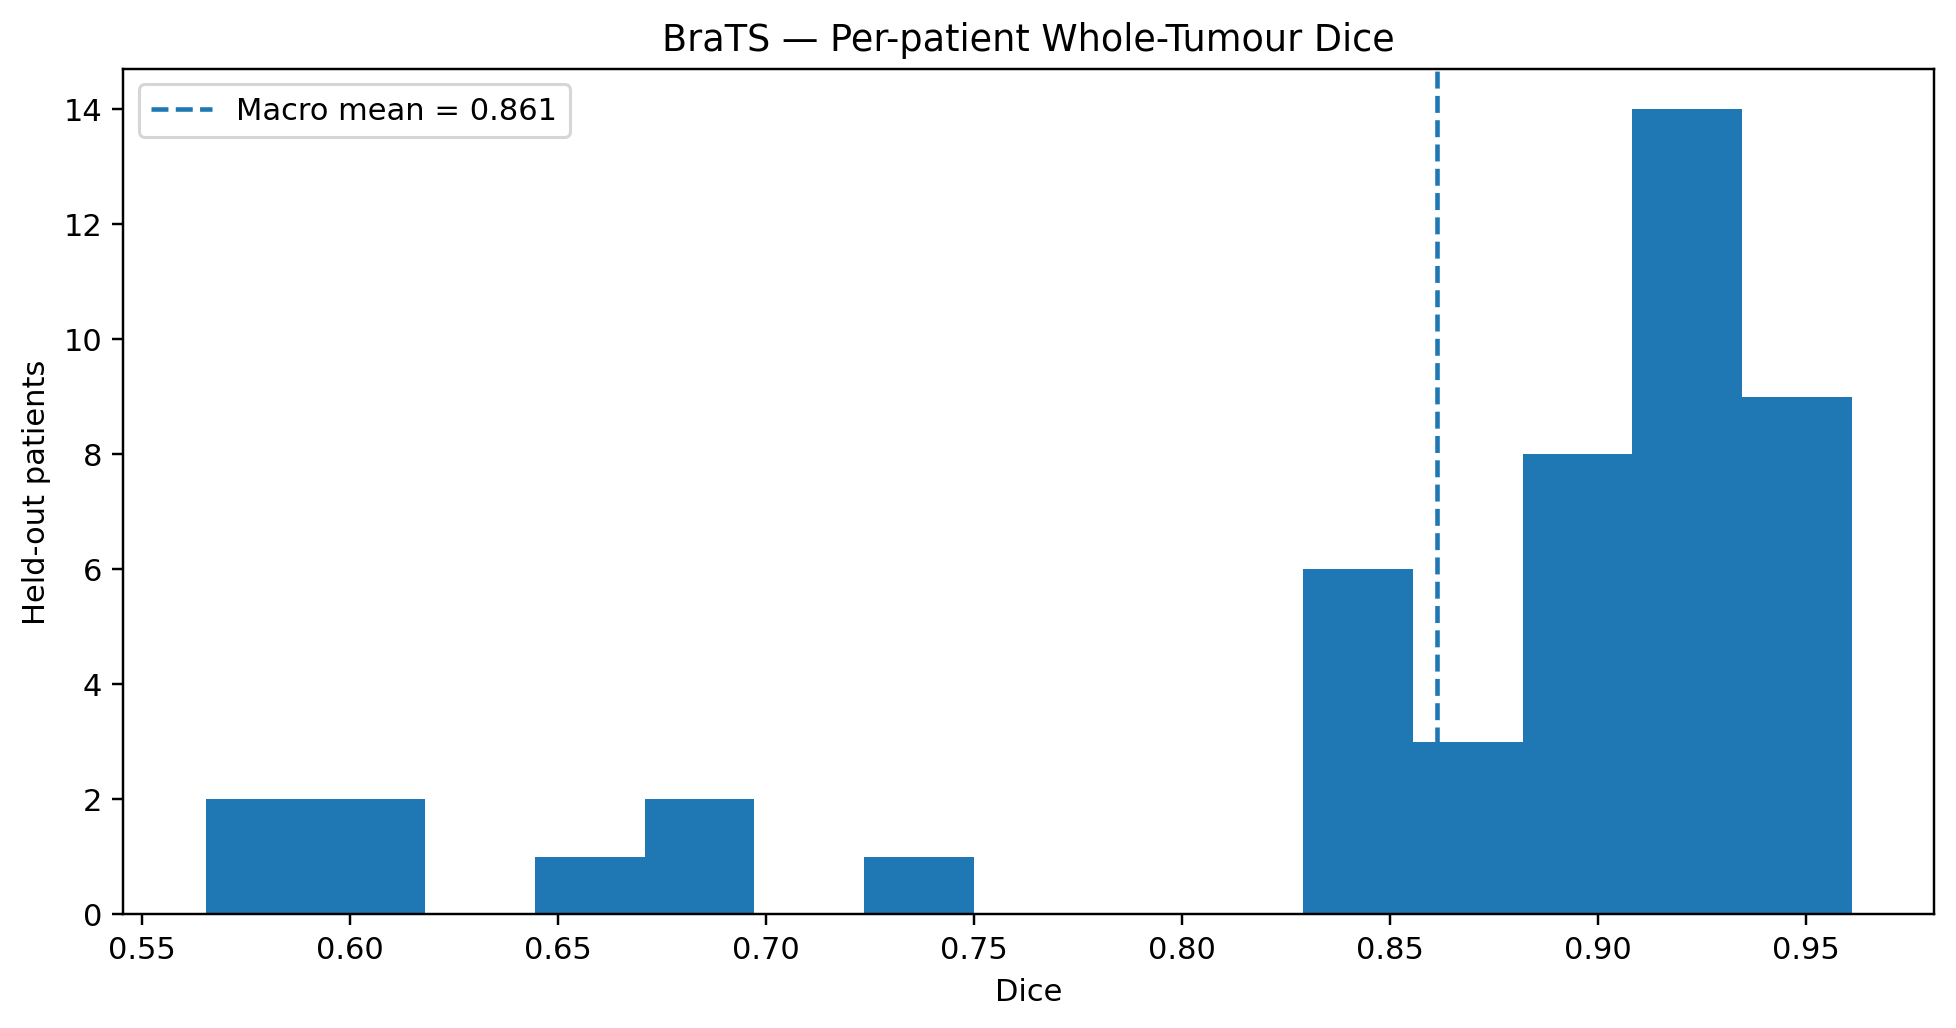

07_BraTS_Per_Patient_IoU.png


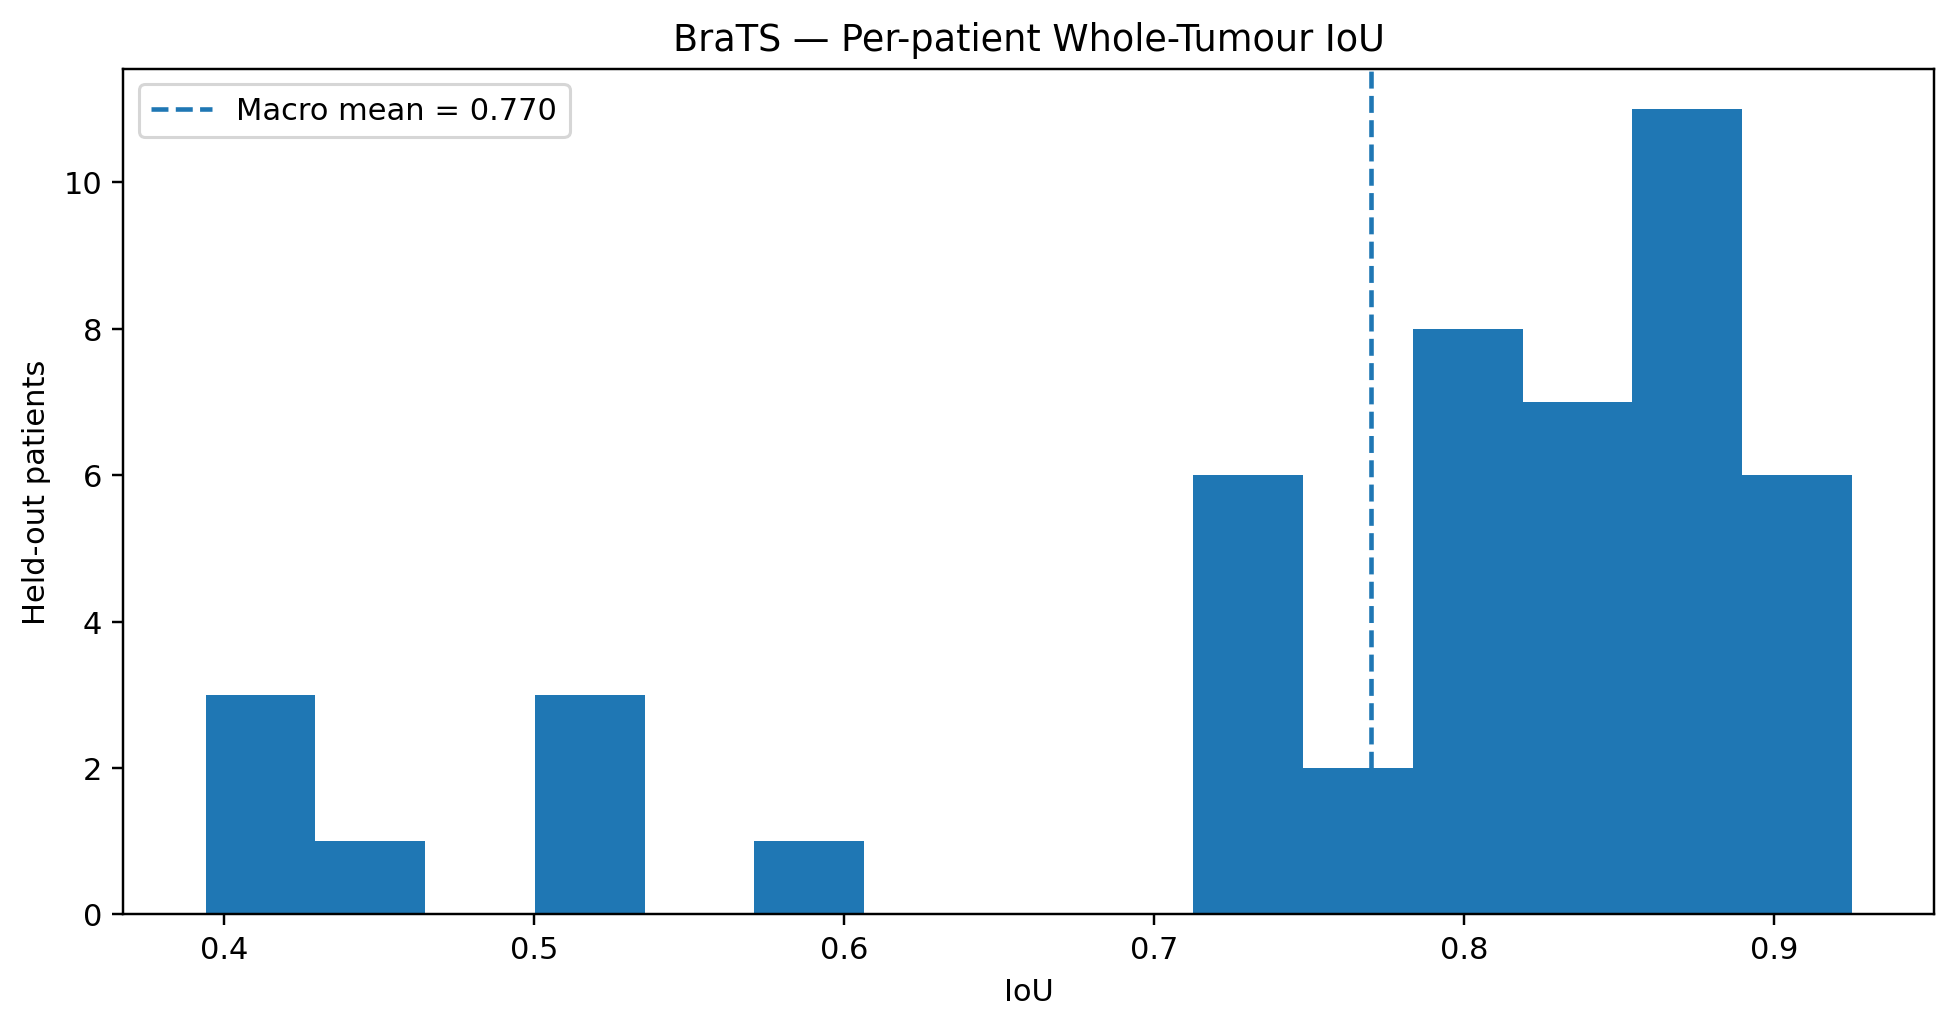

08_BraTS_HD95.png


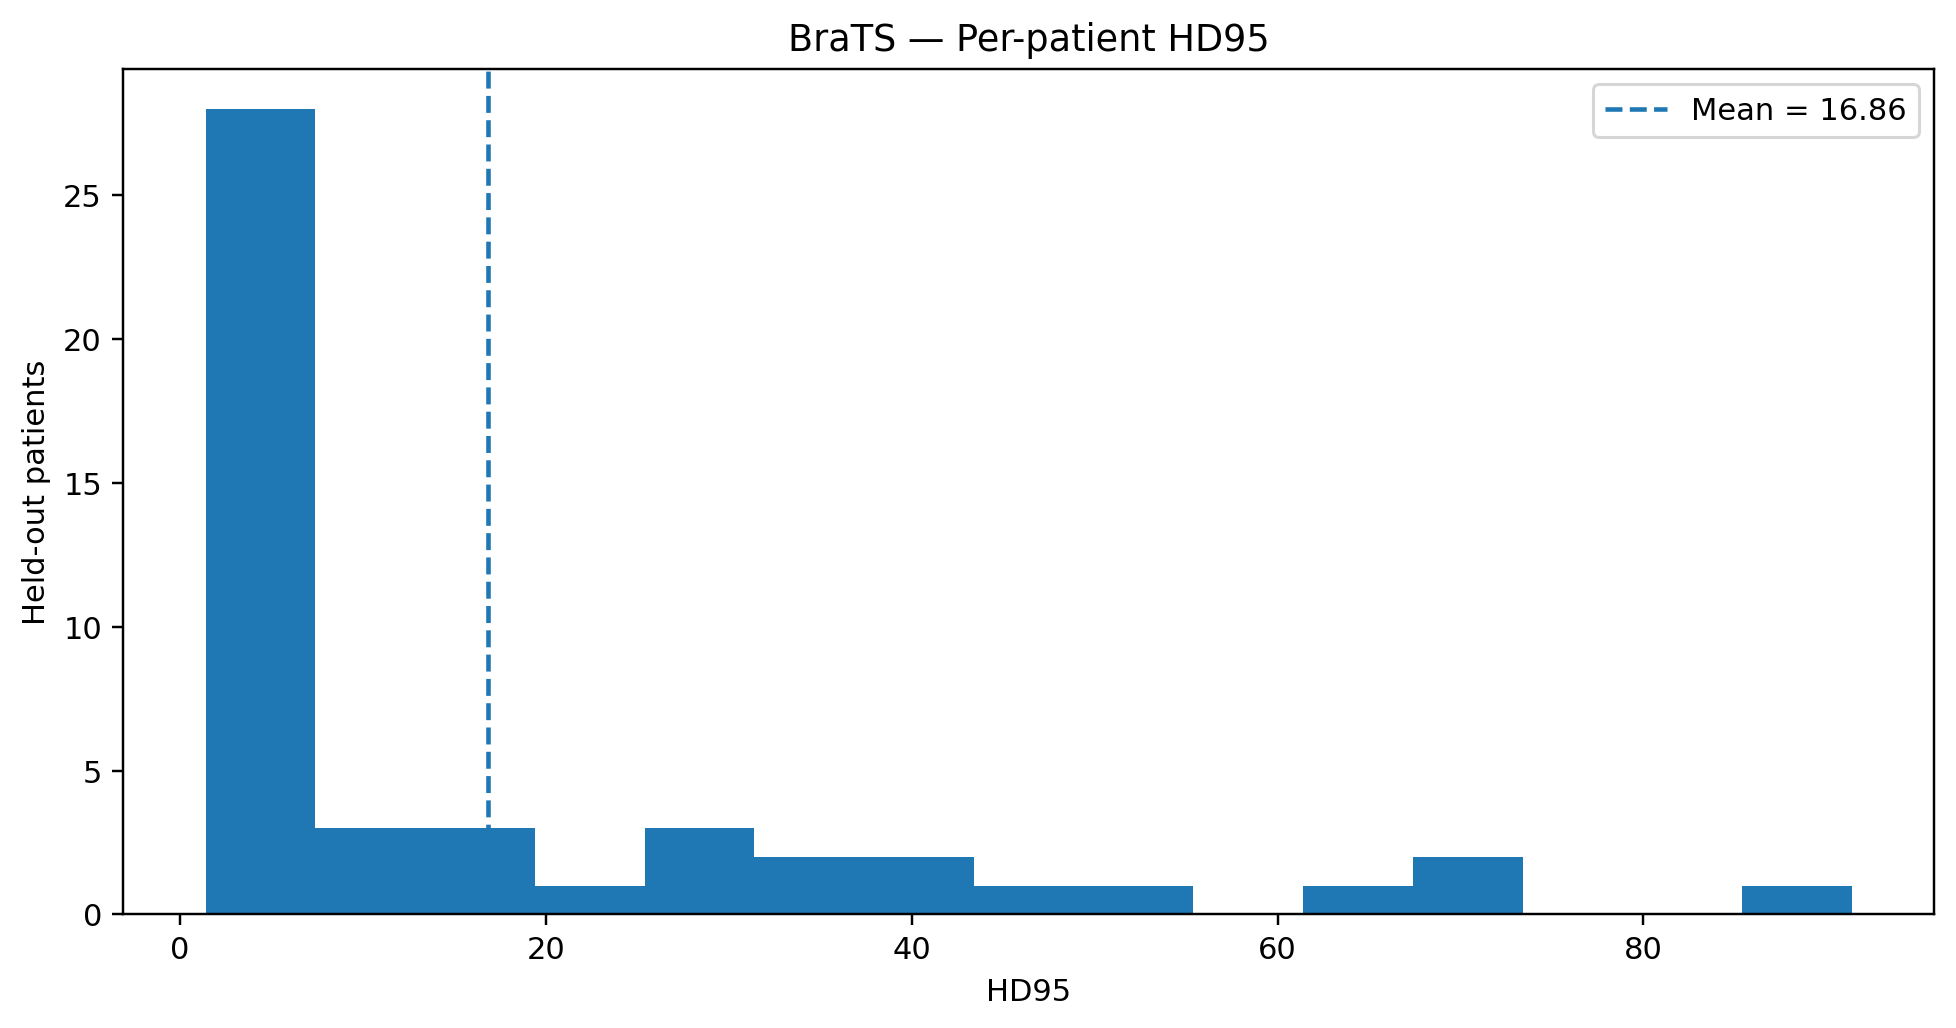

09_BraTS_Validation_Dice_to_Epoch150.png


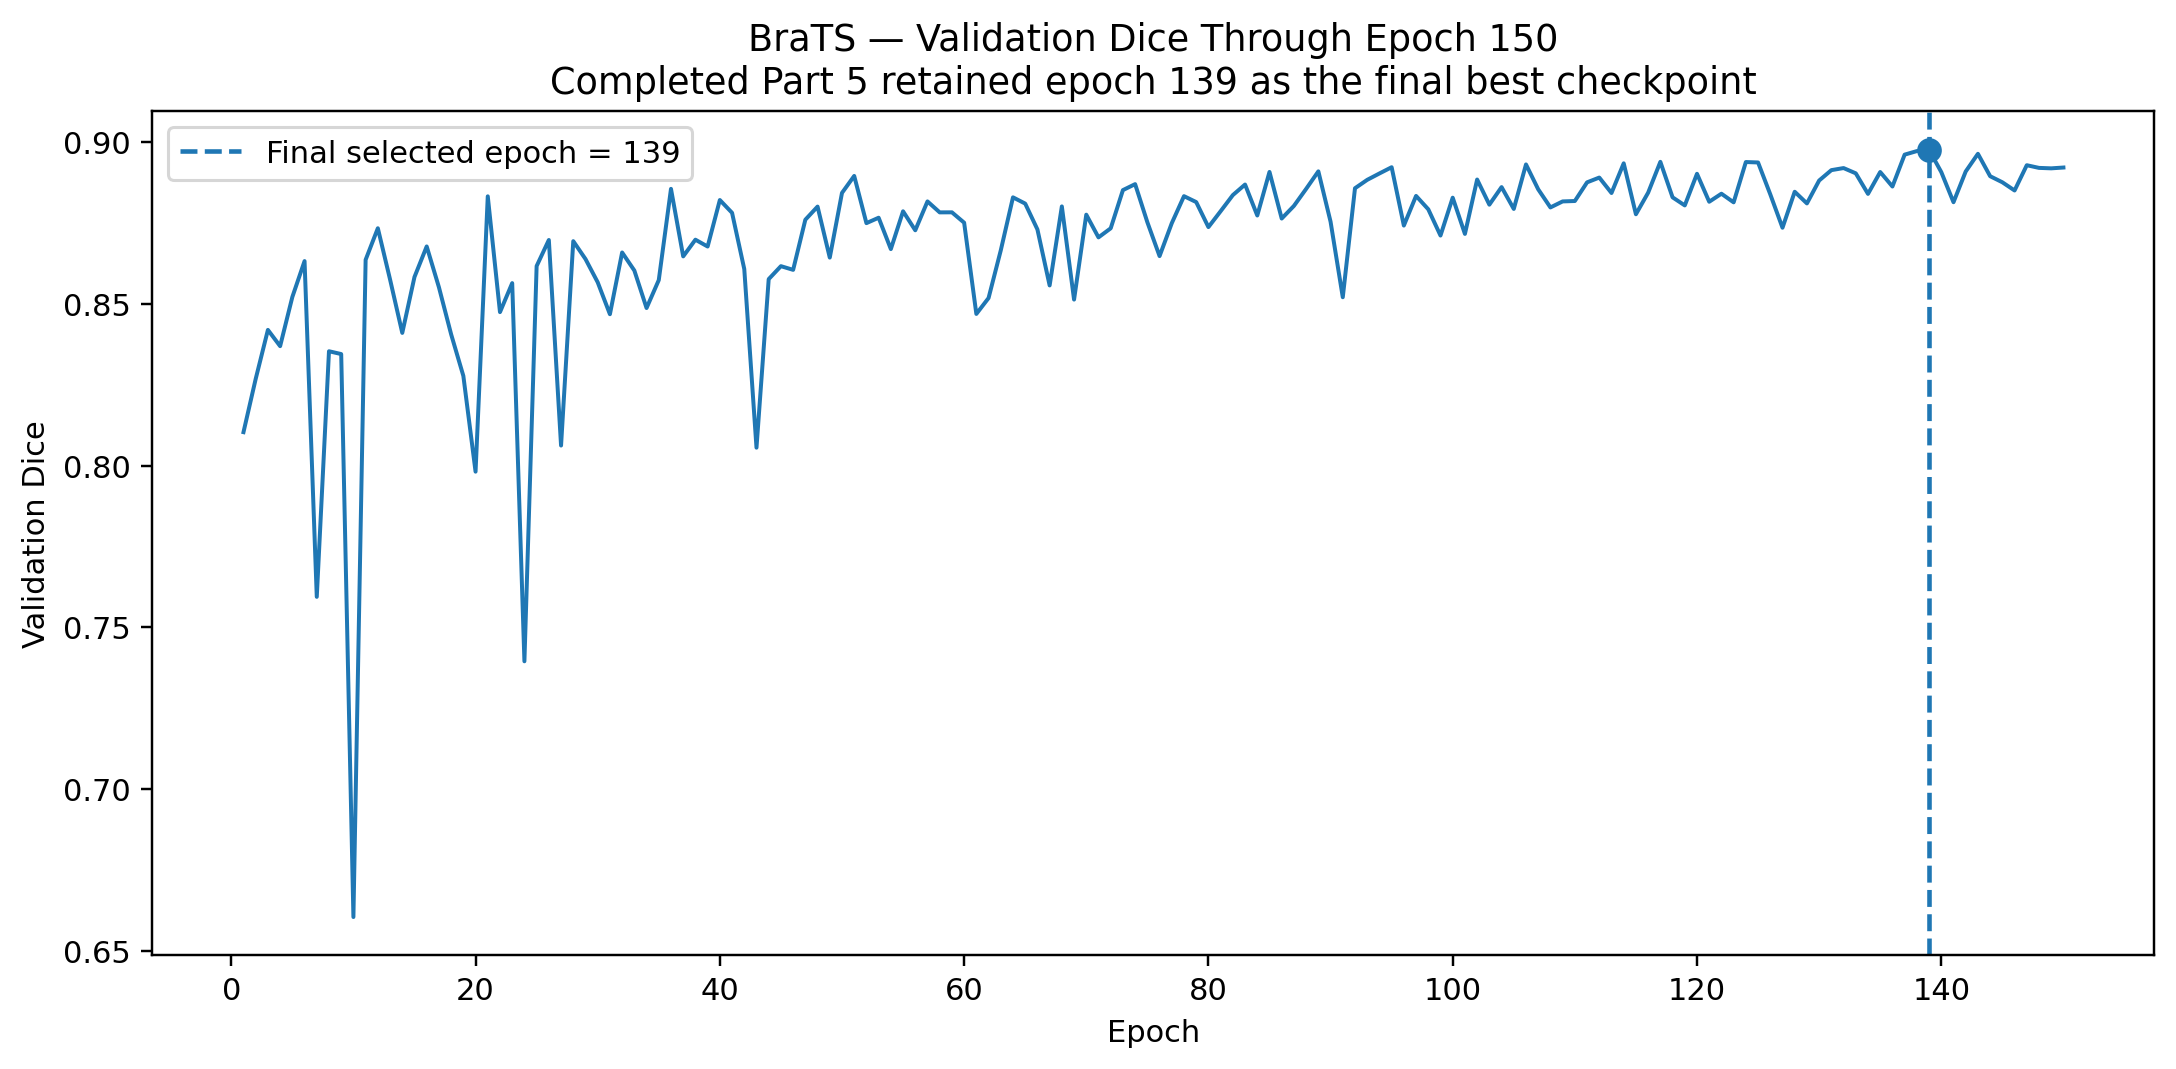

10_EMCAD_Result_Summary.png


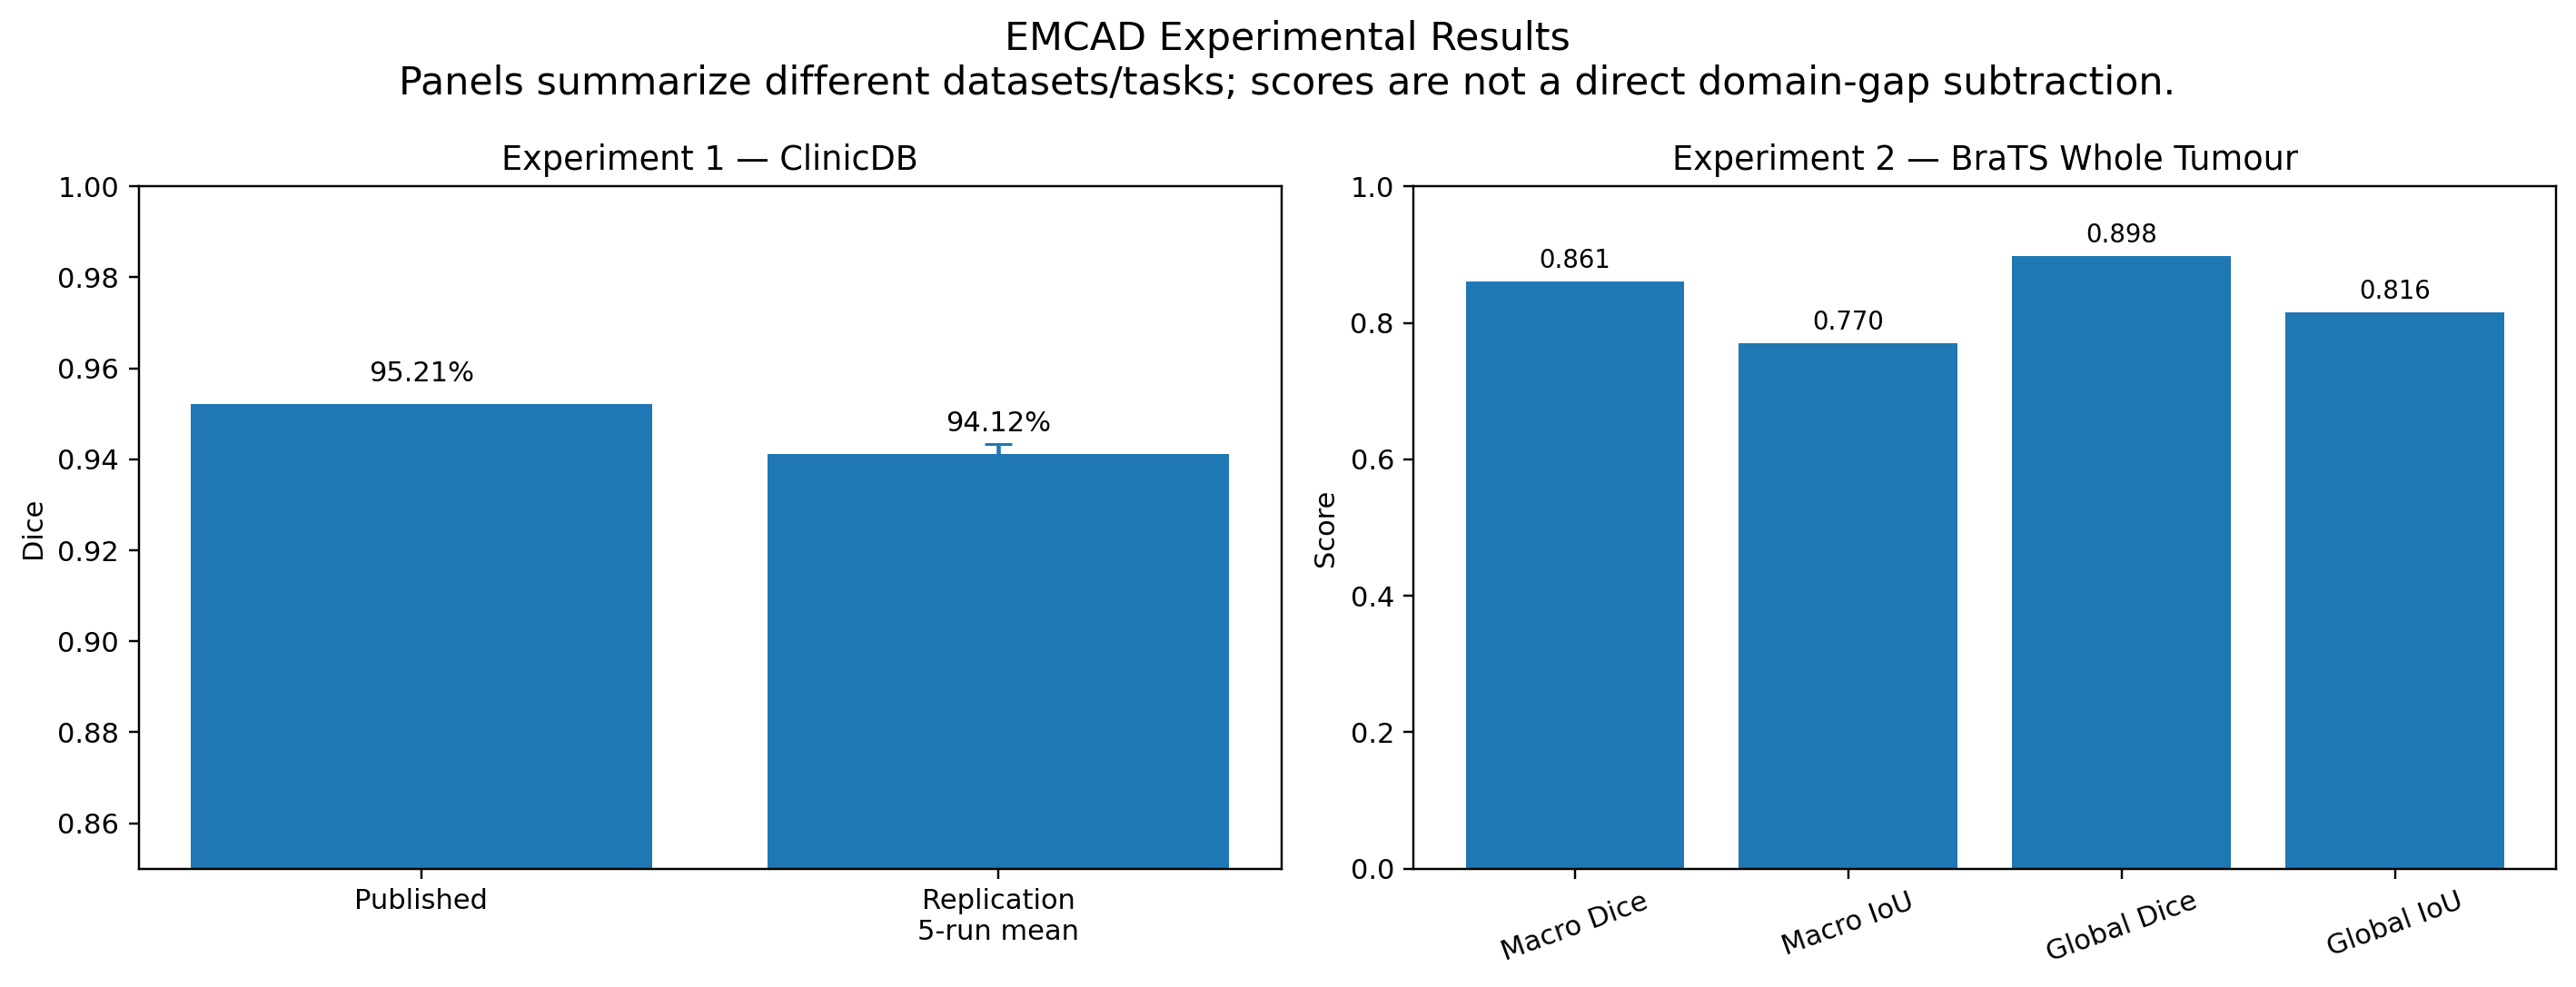

In [11]:
# Display the numerical result figures.

for filename in [
    "02_ClinicDB_Per_Image_Dice.png",
    "03_ClinicDB_Validation_Dice_5Runs.png",
    "04_ClinicDB_Published_vs_Replication.png",
    "06_BraTS_Per_Patient_Dice.png",
    "07_BraTS_Per_Patient_IoU.png",
    "08_BraTS_HD95.png",
    "09_BraTS_Validation_Dice_to_Epoch150.png",
    "10_EMCAD_Result_Summary.png",
]:
    path = OUT / filename
    assert path.is_file(), path
    print(filename)
    display(
        Image(
            filename=str(path)
        )
    )


In [12]:
# Final verification and compact metric display.

import json

report = json.loads(
    (
        OUT
        / "EMCAD_Visualization_Report.json"
    ).read_text()
)

print("CLINICDB")
print("-"*60)
print(
    "Published Dice:",
    f'{report["ClinicDB"]["published_dice"]*100:.2f}%',
)
print(
    "Our 5-run Dice:",
    f'{report["ClinicDB"]["five_run_mean_dice"]*100:.2f}% '
    f'± {report["ClinicDB"]["five_run_std_dice"]*100:.2f}%',
)
print(
    "Our 5-run IoU:",
    f'{report["ClinicDB"]["five_run_mean_iou"]*100:.2f}% '
    f'± {report["ClinicDB"]["five_run_std_iou"]*100:.2f}%',
)

print()
print("BRATS")
print("-"*60)
print(
    "Selected checkpoint epoch:",
    report["BraTS"]["checkpoint_epoch"],
)
print(
    "Validation Dice:",
    f'{report["BraTS"]["validation_dice"]:.4f}',
)
print(
    "Test macro Dice:",
    f'{report["BraTS"]["macro_dice"]["mean"]:.4f} '
    f'± {report["BraTS"]["macro_dice"]["std"]:.4f}',
)
print(
    "Test macro IoU:",
    f'{report["BraTS"]["macro_iou"]["mean"]:.4f} '
    f'± {report["BraTS"]["macro_iou"]["std"]:.4f}',
)
print(
    "Test global Dice:",
    f'{report["BraTS"]["global_dice"]:.4f}',
)
print(
    "Test global IoU:",
    f'{report["BraTS"]["global_iou"]:.4f}',
)
print(
    "HD95:",
    f'{report["BraTS"]["macro_hd95"]["mean"]:.3f} '
    f'± {report["BraTS"]["macro_hd95"]["std"]:.3f}',
)
print(
    "Empty predictions:",
    report["BraTS"]["empty_prediction_patients"],
)

final_zip = (
    WORK
    / "EMCAD_Visualization_Results.zip"
)

assert final_zip.is_file(), final_zip
assert stdout_path.is_file(), stdout_path

print()
print("FINAL OUTPUT")
print(final_zip)
print(
    f"{final_zip.stat().st_size/1024**2:.2f} MiB"
)
print()
print("Save this Kaggle notebook as a Version with outputs.")


CLINICDB
------------------------------------------------------------
Published Dice: 95.21%
Our 5-run Dice: 94.12% ± 0.23%
Our 5-run IoU: 89.45% ± 0.35%

BRATS
------------------------------------------------------------
Selected checkpoint epoch: 139
Validation Dice: 0.8977
Test macro Dice: 0.8613 ± 0.1079
Test macro IoU: 0.7700 ± 0.1469
Test global Dice: 0.8984
Test global IoU: 0.8155
HD95: 16.862 ± 21.851
Empty predictions: 0

FINAL OUTPUT
/kaggle/working/EMCAD_Visualization_Results.zip
4.61 MiB

Save this Kaggle notebook as a Version with outputs.
